# Market of Food and Beverage Establishments in Moscow


### Project Description

Investors from the fund “Shut Up and Take My Money” have decided to try their hand in a new field by opening a food and beverage establishment in Moscow. The clients do not yet know what kind of place it will be—a café, restaurant, pizzeria, pub, or bar—or what its location, menu, and prices will be.

Initially, they are asking you—the analyst—to prepare a market study of Moscow, identify interesting features, and present the results, which will later help in choosing a place that suits the investors' needs.

Try to make the presentation both informative and concise. Its structure and design greatly influence how the information in your study is perceived by its readers. You are free to choose the tools (such as matplotlib, seaborn, etc.) and the types of visualizations on your own.

You have access to a dataset of food and beverage establishments in Moscow, compiled based on data from Yandex Maps and Yandex Business for the summer of 2022. The information posted on Yandex Business might have been added by users or found in publicly available sources. It is provided for reference purposes only.


### Data Description

File `moscow_places.csv`:

- **`name`** — the name of the establishment.
- **`address`** — the address of the establishment.
- **`category`** — the category of the establishment, for example “café”, “pizzeria”, or “coffee shop”.
- **`hours`** — information about the days and hours of operation.
- **`lat`** — the latitude of the geographical point where the establishment is located.
- **`lng`** — the longitude of the geographical point where the establishment is located.
- **`rating`** — the rating of the establishment based on user reviews on Yandex Maps (the highest rating is 5.0).
- **`price`** — the price category of the establishment, for example “average”, “below average”, “above average”, etc.
- **`avg_bill`** — a string that stores the average cost of an order as a range, for example:
  - “Average bill: 1000–1500 ₽”;
  - “Price of a cup of cappuccino: 130–220 ₽”;
  - “Price of a glass of beer: 400–600 ₽”;
  - and so on.
- **`middle_avg_bill`** — a number representing the median bill, provided only for values in the `avg_bill` column that begin with the substring “Average bill”:
  - If the string specifies a price range with two values, the median of these two values will be recorded.
  - If the string specifies a single number—a price without a range—then that number will be recorded.
  - If there is no value or it does not begin with the substring “Average bill”, nothing will be recorded in this column.
- **`middle_coffee_cup`** — a number representing the price of one cup of cappuccino, provided only for values in the `avg_bill` column that begin with the substring “Price of a cup of cappuccino”:
  - If the string specifies a price range with two values, the median of these two values will be recorded.
  - If the string specifies a single number—a price without a range—then that number will be recorded.
  - If there is no value or it does not begin with the substring “Price of a cup of cappuccino”, nothing will be recorded in this column.
- **`chain`** — a number expressed as `0` or `1` that indicates whether the establishment is part of a chain (note: small chains may have errors):
  - `0` — the establishment is not part of a chain.
  - `1` — the establishment is part of a chain.
- **`district`** — the administrative district in which the establishment is located, for example the Central Administrative Okrug.
- **`seats`** — the number of seating places.


## Step 1. Data Overview

Load the data on Moscow’s food and beverage establishments.  
File path: `/datasets/moscow_places.csv`. Download the dataset.  
Examine the general information about the dataset. How many establishments are represented? What can you say about each column? What data types do they store?


In [1]:
!pip install folium

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from plotly import graph_objects as go
import plotly.express as px
import re
import requests 
import json
from folium import Map, Choropleth
from folium import Map, Marker
from folium.plugins import MarkerCluster
from folium.features import CustomIcon

In [3]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/moscow_places.csv')
df.head(10)

,name,category,address,district,hours,lat,lng,rating,price,avg_bill,middle_avg_bill,middle_coffee_cup,chain,seats
0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",55.878494,37.478860,5.0,NaN,NaN,NaN,NaN,0,NaN
1,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",55.875801,37.484479,4.5,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,0,4.0
2,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",55.889146,37.525901,4.6,средние,Средний счёт:от 1000 ₽,1000.0,NaN,0,45.0
3,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",55.881608,37.488860,5.0,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0,0,NaN
4,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",55.881166,37.449357,5.0,средние,Средний счёт:400–600 ₽,500.0,NaN,1,148.0
5,Sergio Pizza,пиццерия,"Москва, Ижорская улица, вл8Б",Северный административный округ,"ежедневно, 10:00–23:00",55.888010,37.509573,4.6,средние,NaN,NaN,NaN,0,NaN
6,Огни города,"бар,паб","Москва, Клязьминская улица, 9, стр. 3",Северный административный округ,пн 15:00–04:00; вт-вс 15:00–05:00,55.890752,37.524653,4.4,средние,Средний счёт:199 ₽,199.0,NaN,0,45.0
7,Mr. Уголёк,быстрое питание,"Москва, Клязьминская улица, 9, стр. 3",Северный административный округ,"пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00...",55.890636,37.524303,4.7,средние,Средний счёт:200–300 ₽,250.0,NaN,0,45.0
8,Donna Maria,ресторан,"Москва, Дмитровское шоссе, 107, корп. 4",Северный административный округ,"ежедневно, 10:00–22:00",55.880045,37.539006,4.8,средние,Средний счёт:от 500 ₽,500.0,NaN,0,79.0
9,Готика,кафе,"Москва, Ангарская улица, 39",Северный административный округ,"ежедневно, 12:00–00:00",55.879038,37.524487,4.3,средние,Средний счёт:1000–1200 ₽,1100.0,NaN,0,65.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               8406 non-null   object 
 1   category           8406 non-null   object 
 2   address            8406 non-null   object 
 3   district           8406 non-null   object 
 4   hours              7870 non-null   object 
 5   lat                8406 non-null   float64
 6   lng                8406 non-null   float64
 7   rating             8406 non-null   float64
 8   price              3315 non-null   object 
 9   avg_bill           3816 non-null   object 
 10  middle_avg_bill    3149 non-null   float64
 11  middle_coffee_cup  535 non-null    float64
 12  chain              8406 non-null   int64  
 13  seats              4795 non-null   float64
dtypes: float64(6), int64(1), object(7)
memory usage: 919.5+ KB


### Checking for Missing Values

In [5]:
# Checking for Missing Values
df.isna().sum()

name                    0
category                0
address                 0
district                0
hours                 536
lat                     0
lng                     0
rating                  0
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
chain                   0
seats                3611
dtype: int64

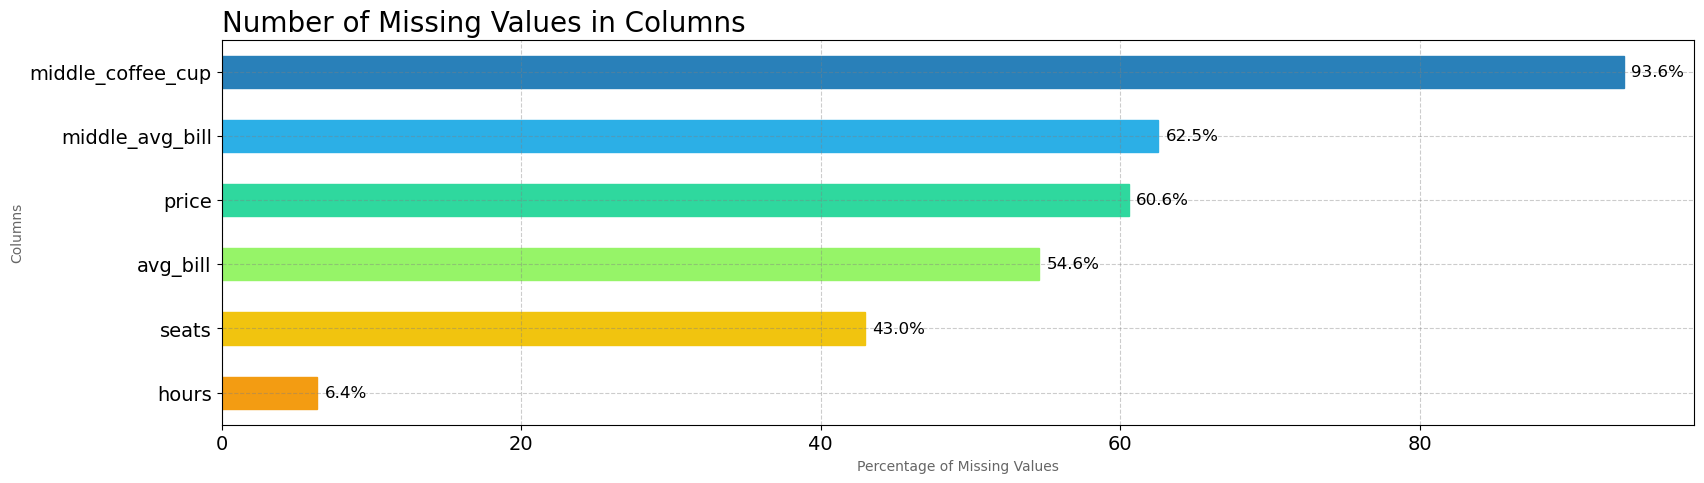

In [6]:
def pass_value_barh(data):
    try:
        # Calculate the percentage of missing values and convert it into a DataFrame
        missing_data = (data.isna().mean() * 100).to_frame(name='space')
        # Filter out columns with missing values and sort them
        missing_data = missing_data.query('space > 0').sort_values(by='space', ascending=True)
        
        # Color palette for the columns
        colors = ['#f39c12', '#f1c40f', '#96f468', '#2fd89e', '#2cafe6', '#2980b9']
        # Select as many colors as there are columns with missing values
        colors = colors[:len(missing_data)]

        # Plot a horizontal bar chart
        ax = missing_data.plot(
            kind='barh',
            figsize=(19, 5),
            rot=0,
            legend=False,
            fontsize=14
        )
        
        # Manually apply colors to each bar
        for idx, bar in enumerate(ax.patches):
            bar.set_color(colors[idx % len(colors)])
        
        ax.set_title('Number of Missing Values in Columns', fontsize=20, loc='Left')
        ax.set_xlabel('Percentage of Missing Values', alpha=0.6)
        ax.set_ylabel('Columns', alpha=0.6)
        
        # Add a grid with the specified settings
        ax.grid(True, which='major', axis='both', linestyle='--', color='gray', alpha=0.4)
        
        # Add percentage labels for each column
        for index, value in enumerate(missing_data['space']):
            ax.text(value + 0.5, index, f'{value:.1f}%', va='center', fontsize=12)
        
        plt.show()
    except Exception as e:
        print(f'No missing values remain :) or an error occurred in the first part of the function: {e}')

# Calling the function with the DataFrame
pass_value_barh(df)

### Checking for Duplicates

In [7]:
# Check for obvious duplicates
print(f"Number of obvious duplicates: {df.duplicated().sum()}")

Number of obvious duplicates: 0


In [8]:
# Check for non-obvious duplicates
print(f"Number of establishments with the same name: "
      f"{df['name'].str.lower().duplicated().sum()}")

print(f"Number of establishments with the same address: "
      f"{df['address'].str.lower().duplicated().sum()}")

Number of establishments with the same name: 2894
Number of establishments with the same address: 2654


The DataFrame contains establishments with the same address and name,  but these could be branches of the same chain or establishments located at the same address.

In [9]:
print(f"Number of duplicates based on the columns 'name', 'address': "
      f"{df.duplicated(subset=['name', 'address']).sum()}")

print(f"Number of duplicates based on the columns 'lat', 'lng': "
      f"{df.duplicated(subset=['lat', 'lng']).sum()}")

print(f"Number of duplicates based on the columns 'name', 'lat', 'lng': "
      f"{df.duplicated(subset=['name', 'lat', 'lng']).sum()}")

Number of duplicates based on the columns 'name', 'address': 0
Number of duplicates based on the columns 'lat', 'lng': 34
Number of duplicates based on the columns 'name', 'lat', 'lng': 0


In [10]:
print(f"Number of unique establishment names: {df['name'].str.lower().nunique()}")

Number of unique establishment names: 5512


**Conclusion:**

The DataFrame contains 8406 records, including 5512 unique establishments and 2894 records corresponding to chain establishments.

**Data Types:**
- The columns `name`, `category`, `address`, `district`, `hours`, `price`, and `avg_bill` contain text data (object), which describe the establishment’s name, category, address, district, operating hours, price category, and average bill.
- The columns `lat` and `lng` contain coordinates as floats.
- The `rating` column contains the establishment’s rating as a float.
- The columns `middle_avg_bill` and `middle_coffee_cup` contain numerical values for the average bill and the cost of a cup of cappuccino (floats).
- The `chain` column contains a numerical indicator (`int64`) that specifies whether the establishment is part of a chain.
- The `seats` column stores information on the number of seating places as floating point numbers (`float64`); it needs to be converted to an integer.

**Missing Values:** are present in the following columns:
- `hours` — 536 (6.4%)
- `price` — 5091 (60.6%)
- `avg_bill` — 4590 (54.6%)
- `middle_avg_bill` — 5257 (62.5%)
- `middle_coffee_cup` — 7871 (93.6%)
- `seats` — 3611 (43%)

**Duplicates:** No obvious or non-obvious duplicates were found.


## Step 2. Data Preprocessing

Examine whether there are duplicates in the data. Look for missing values: do they exist, and in which columns? Can they be processed or left as is?  
Perform data preprocessing:
- Create a column `street` with the street names extracted from the address column.
- Create a column `is_24_7` indicating that the establishment operates every day and 24/7:
  - Logical value `True` — if the establishment operates daily and around the clock;
  - Logical value `False` — otherwise.


### Data Types


In [11]:
# Convert the 'seats' column to int format.
df['seats'] = df['seats'].astype('Int64')  # Note the capital 'I'
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               8406 non-null   object 
 1   category           8406 non-null   object 
 2   address            8406 non-null   object 
 3   district           8406 non-null   object 
 4   hours              7870 non-null   object 
 5   lat                8406 non-null   float64
 6   lng                8406 non-null   float64
 7   rating             8406 non-null   float64
 8   price              3315 non-null   object 
 9   avg_bill           3816 non-null   object 
 10  middle_avg_bill    3149 non-null   float64
 11  middle_coffee_cup  535 non-null    float64
 12  chain              8406 non-null   int64  
 13  seats              4795 non-null   Int64  
dtypes: Int64(1), float64(5), int64(1), object(7)
memory usage: 927.7+ KB


### Missing Values

The table shows a significant number of missing values, especially regarding prices. Unfortunately, these data cannot be recovered within the scope of the project.

The `middle_coffee_cup` column has missing values almost everywhere. Filling these with other values may distort the data.

Perhaps some of the `price` values can be filled using data from `avg_bill` (there are 501 fewer missing values in `avg_bill`). Let's check:


In [12]:
# Filtering rows where avg_bill is not missing, starts with "Средний счёт", and price is missing
len(df[(df['avg_bill'].notna()) & 
       (df['avg_bill'].str.startswith('Средний счёт', na=False)) & 
       (df['price'].isna())])


470

470 rows can be filled (a total of 6%). Since the `price` column is of type object, it is simpler and faster to replace the missing values with 'Не определено'.


In [13]:
df['price'] = df['price'].fillna('Не определено')

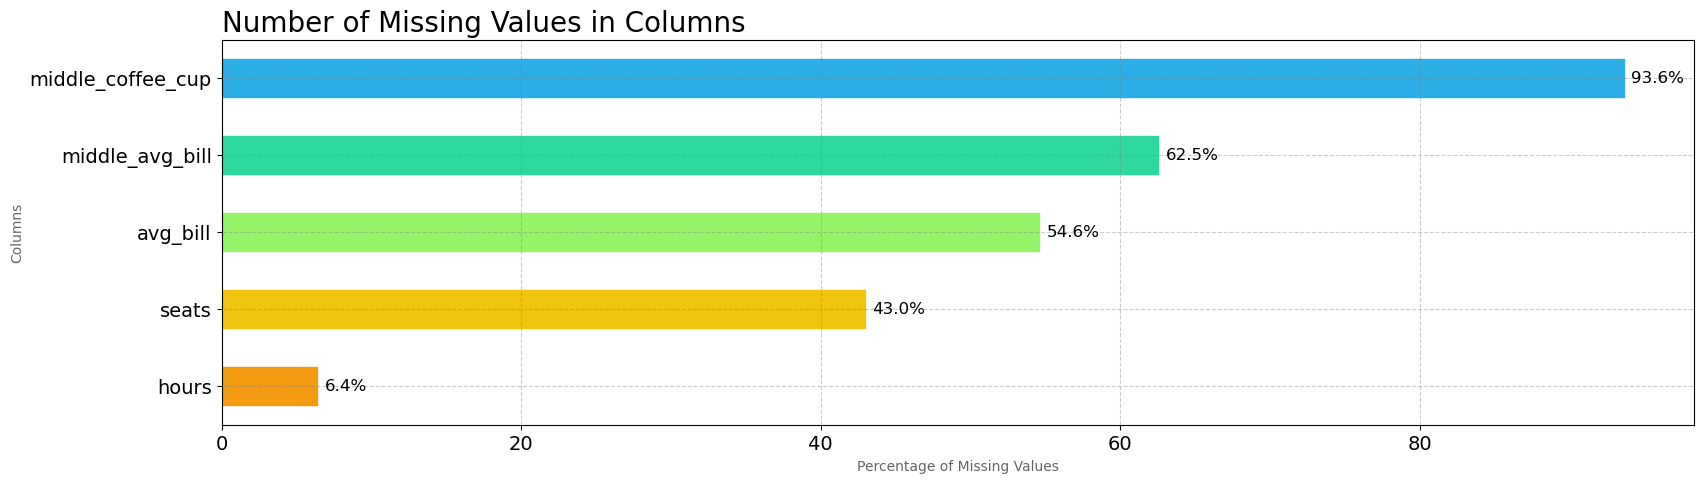

In [14]:
# Checking
pass_value_barh(df)

Missing values in `price` have been removed.


In [15]:
# Count the number of rows for each category in the 'price' column
df['price'].value_counts(dropna=False).to_frame()


,count
price,
Не определено,5091
средние,2117
выше среднего,564
высокие,478
низкие,156


**Conclusion:**  
In the `price` column, the missing values were replaced with 'Не определено'. In all other cases, NaN values were left unchanged.


### Renaming Values in Columns

We will rename the values in the column with district names for convenience.


In [16]:
# Create a dictionary for replacement
district_rename = {
    'Центральный административный округ': 'ЦАО',
    'Северо-Восточный административный округ': 'СВАО',
    'Северный административный округ': 'САО',
    'Западный административный округ': 'ЗАО',
    'Южный административный округ': 'ЮАО',
    'Восточный административный округ': 'ВАО',
    'Юго-Западный административный округ': 'ЮЗАО',
    'Юго-Восточный административный округ': 'ЮВАО',
    'Северо-Западный административный округ': 'СЗАО'
}

# Create a new column 'district_short'
df['district_short'] = df['district'].replace(district_rename)

# Check the result
df.head()


,name,category,address,district,hours,lat,lng,rating,price,avg_bill,middle_avg_bill,middle_coffee_cup,chain,seats,district_short
0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",55.878494,37.478860,5.0,Не определено,NaN,NaN,NaN,0,<NA>,САО
1,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",55.875801,37.484479,4.5,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,0,4,САО
2,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",55.889146,37.525901,4.6,средние,Средний счёт:от 1000 ₽,1000.0,NaN,0,45,САО
3,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",55.881608,37.488860,5.0,Не определено,Цена чашки капучино:155–185 ₽,NaN,170.0,0,<NA>,САО
4,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",55.881166,37.449357,5.0,средние,Средний счёт:400–600 ₽,500.0,NaN,1,148,САО


### Creating New Columns

Create a new column `street` with street names extracted from the address column.


In [17]:
# Create a new column 'street' using a regular expression
# Extract street, park, square, and other object names considering various formats
df['street'] = df['address'].str.extract(
    r'Москва,\s*([\w\s\.\-№()]+?(?:улица|ул\.|проспект|сквер|парк|проезд|заказник|дублёр)?[\w\s\-()]*?)(?:,|$)',
    expand=False
)

df.head()


,name,category,address,district,hours,lat,lng,rating,price,avg_bill,middle_avg_bill,middle_coffee_cup,chain,seats,district_short,street
0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",55.878494,37.478860,5.0,Не определено,NaN,NaN,NaN,0,<NA>,САО,улица Дыбенко
1,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",55.875801,37.484479,4.5,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,0,4,САО,улица Дыбенко
2,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",55.889146,37.525901,4.6,средние,Средний счёт:от 1000 ₽,1000.0,NaN,0,45,САО,Клязьминская улица
3,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",55.881608,37.488860,5.0,Не определено,Цена чашки капучино:155–185 ₽,NaN,170.0,0,<NA>,САО,улица Маршала Федоренко
4,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",55.881166,37.449357,5.0,средние,Средний счёт:400–600 ₽,500.0,NaN,1,148,САО,Правобережная улица


In [18]:
# Check how many missing values remain in the 'street' column
df['street'].isna().value_counts()


street
False    8406
Name: count, dtype: int64

In [19]:
# Print out the list of streets
df['street'].unique().tolist()


['улица Дыбенко',
 'Клязьминская улица',
 'улица Маршала Федоренко',
 'Правобережная улица',
 'Ижорская улица',
 'Дмитровское шоссе',
 'Ангарская улица',
 'Левобережная улица',
 'МКАД',
 'Базовская улица',
 'улица Бусиновская Горка',
 'Ленинградское шоссе',
 'Коровинское шоссе',
 'Ижорский проезд',
 'Прибрежный проезд',
 'Лобненская улица',
 'парк Левобережный',
 'Угличская улица',
 'Абрамцевская улица',
 'ландшафтный заказник Лианозовский',
 'Череповецкая улица',
 'Алтуфьевское шоссе',
 'Лианозовский парк культуры и отдыха',
 'Дубнинская улица',
 'Илимская улица',
 'Шенкурский проезд',
 'Новгородская улица',
 'парк Алтуфьево',
 'улица Пришвина',
 'бульвар Академика Ландау',
 'улица Лескова',
 'улица Плещеева',
 'Бибиревская улица',
 'Лианозовский проезд',
 'Челобитьевское шоссе',
 'Костромская улица',
 'Карельский бульвар',
 'Инженерная улица',
 'парк Ангарские пруды',
 'улица Софьи Ковалевской',
 'улица Корнейчука',
 'Проектируемый проезд № 5265',
 'улица Римского-Корсакова',
 'улица

Create the column 'is_24_7' by checking the conditions for daily and 24/7 operation

In [20]:
# Print all unique operating hours of the establishments
df['hours'].unique().tolist()

['ежедневно, 10:00–22:00',
 'пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00–02:00',
 'ежедневно, 09:00–22:00',
 'ежедневно, 10:00–23:00',
 'пн 15:00–04:00; вт-вс 15:00–05:00',
 'пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00–22:00',
 'ежедневно, 12:00–00:00',
 'ежедневно, круглосуточно',
 'ежедневно, 10:00–21:00',
 'вт-сб 09:00–18:00',
 'ежедневно, 08:00–22:00',
 'ежедневно, 13:00–00:00',
 'пн-пт 08:30–18:30; сб 10:00–20:00',
 'ежедневно, 09:00–21:00',
 'пн-пт 09:00–21:00',
 'пн-чт 11:00–22:00; пт,сб 11:00–23:00; вс 11:00–22:00',
 'пн-пт 08:00–22:00; сб,вс 10:00–22:00',
 'ежедневно, 10:00–19:00',
 'пн-пт 09:00–16:00',
 'ежедневно, 08:00–21:00',
 'ежедневно, 09:00–23:00',
 'ежедневно, 08:00–23:00',
 nan,
 'пн-пт 08:00–18:00',
 'пн-пт 09:00–19:00',
 'ежедневно, 11:00–00:00',
 'ежедневно, 09:00–02:00',
 'ежедневно, 12:00–23:00',
 'ежедневно, 12:00–03:00',
 'ежедневно, 16:00–06:00',
 'пн-чт 12:30–00:00; пт,сб 12:30–02:00; вс 12:30–00:00',
 'пн-сб 11:00–23:00; вс 12:00–23:00',
 'пн-пт 08:00

In [21]:
# Create the column 'is_24_7' by checking the conditions for daily and 24/7 operation
df['is_24_7'] = df['hours'].str.contains(r'ежедневно.*(?:00:00|24:00|круглосуточно)', case=False, na=False)

df.head()

,name,category,address,district,hours,lat,lng,rating,price,avg_bill,middle_avg_bill,middle_coffee_cup,chain,seats,district_short,street,is_24_7
0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",55.878494,37.478860,5.0,Не определено,NaN,NaN,NaN,0,<NA>,САО,улица Дыбенко,False
1,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",55.875801,37.484479,4.5,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,0,4,САО,улица Дыбенко,False
2,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",55.889146,37.525901,4.6,средние,Средний счёт:от 1000 ₽,1000.0,NaN,0,45,САО,Клязьминская улица,False
3,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",55.881608,37.488860,5.0,Не определено,Цена чашки капучино:155–185 ₽,NaN,170.0,0,<NA>,САО,улица Маршала Федоренко,False
4,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",55.881166,37.449357,5.0,средние,Средний счёт:400–600 ₽,500.0,NaN,1,148,САО,Правобережная улица,False


In [22]:
df['is_24_7'].value_counts()

is_24_7
False    7034
True     1372
Name: count, dtype: int64

A total of 1372 establishments operate 24/7.


**Conclusion:**

**Data Types:**
- The `seats` column has been converted to the Int64 format (which allows storing both integer values and missing values in one column).

**Missing Values:**
- `price` — 5091 (60.6%) were replaced with "Не определено" ("Undefined").
- All other missing values were left as is.

**Creation of New Columns:**
- A new column `street` has been created, containing street names extracted from the address.
- A new column `is_24_7` has been created to indicate if the establishment operates daily and around the clock.


## Step 3. Data Analysis

### Distribution of Establishments by Category

Which categories of establishments are represented in the data?  
Examine the number of food and beverage objects by category: restaurants, cafés, coffee shops, pizzerias, bars, etc. Create visualizations.  
Answer the question regarding the distribution of establishments by category.


In [23]:
# Create a dictionary to map Russian category names to English
category_mapping = {
    'кафе': 'cafe',
    'ресторан': 'restaurant',
    'кофейня': 'coffee shop',
    'пиццерия': 'pizzeria',
    'бар,паб': 'bars and pubs',
    'быстрое питание': 'fast food',
    'столовая': 'canteen',
    'булочная': 'bakery'
}

# Replace the values in the 'category' column using the mapping dictionary
df['category'] = df['category'].replace(category_mapping)

# Verify the changes
df['category'].unique()


array(['cafe', 'restaurant', 'coffee shop', 'pizzeria', 'bars and pubs',
       'fast food', 'bakery', 'canteen'], dtype=object)

In [24]:
category_counts = df['category'].value_counts()
category_counts.to_frame()

,count
category,
cafe,2378
restaurant,2043
coffee shop,1413
bars and pubs,765
pizzeria,633
fast food,603
canteen,315
bakery,256


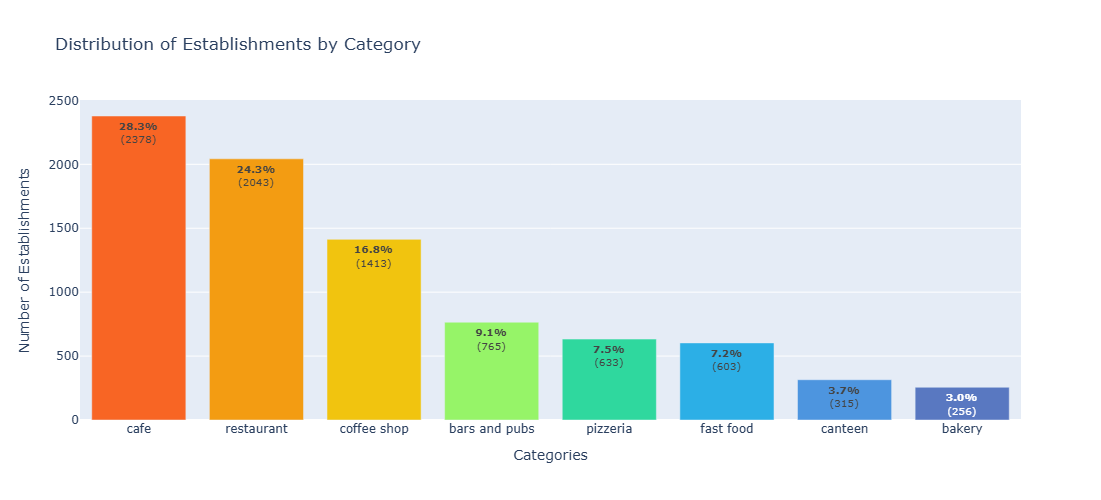

In [25]:
# Calculate percentages
total = category_counts.sum()
percentages = (category_counts / total * 100).round(1)

# Create a bar chart
fig = go.Figure(data=[
    go.Bar(
        x=category_counts.index,  # Category labels
        y=category_counts.values,  # Values
        text=[f"<b>{percent}%</b><br>({value})" for value, percent in zip(category_counts.values, percentages)],  # Display text
        textposition='inside',  # Text inside the bars
        insidetextanchor='end',  # Position text centered
        marker=dict(
            color=['#f86524', '#f39c12', '#f1c40f', 
                   '#96f468', '#2fd89e', '#2cafe6', '#4d95df', '#5978c1']  # Colors
        ),
    )
])

# Set up the layout
fig.update_layout(
    title='Distribution of Establishments by Category',
    xaxis_title='Categories',
    yaxis_title='Number of Establishments',
    width=1000,  # Chart width
    height=500,  # Chart height
    uniformtext_minsize=10,  # Minimum text size
    uniformtext_mode='show',  # Ensure the text is displayed
)

fig.show()


- **Café** – the most popular category, constituting **28.3%** of the total (2378 establishments).
- **Restaurants** – the second most common, covering **24.3%** of the market (2043 establishments).
- **Coffee Shops** – represent **16.8%** (1413 establishments).
- **Bars and Pubs** – make up **9.1%** (765 establishments).
- **Pizzerias** – account for **7.53%** (633 establishments).
- **Fast Food** – covers **7.17%** of the market (603 establishments).
- **Canteens** – are represented in **3.75%** of cases (315 establishments).
- **Bakeries** – constitute the smallest share, **3.05%** (256 establishments).

 ---

 **Conclusion:**

The main categories of establishments are **cafés** and **restaurants**, which together account for **52.6%** of the market. These two types of establishments occupy key positions and determine the majority of customer preferences.


## Distribution of Seating Capacity by Categories

Investigate the seating capacity of establishments by categories: restaurants, cafés, coffee shops, pizzerias, bars, etc. Create visualizations. Analyze the results and draw conclusions.


In [26]:
df['seats'].describe().to_frame()

,seats
count,4795.0
mean,108.421689
std,122.833396
min,0.0
25%,40.0
50%,75.0
75%,140.0
max,1288.0


Most establishments have between 40 and 140 seats. However, there are very small establishments as well as large venues with more than 1000 seats. The average is 108 seats, the median is 75, and the maximum is 1288.

Let's see how the seating capacities are distributed.


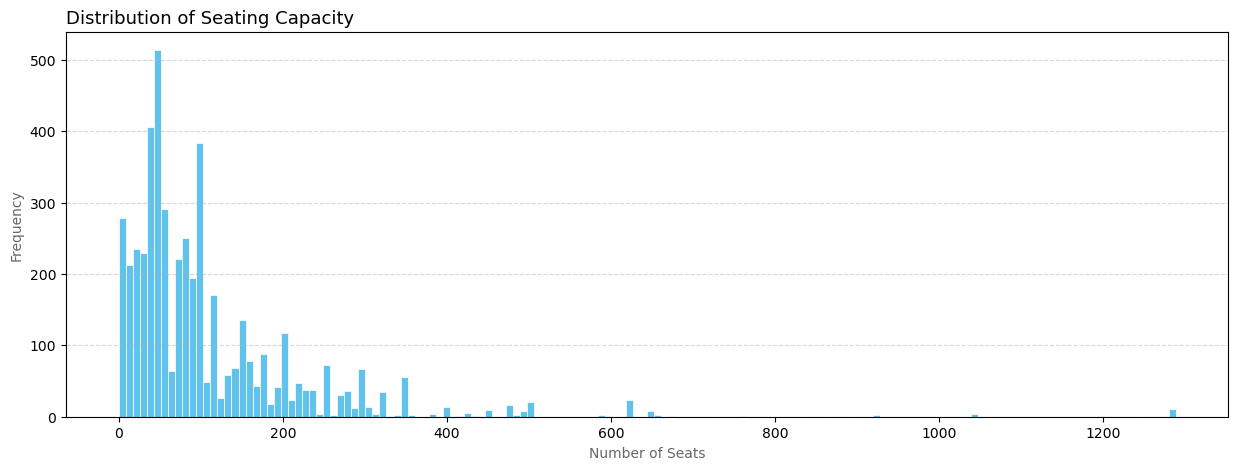

In [27]:
plt.figure(figsize=(15, 5))
sns.histplot(data=df, x='seats', bins=150, kde=False, color='#2cafe6', edgecolor='white')
plt.title('Distribution of Seating Capacity', fontsize=13, loc='left')
plt.xlabel('Number of Seats', alpha=0.6)
plt.ylabel('Frequency', alpha=0.6)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


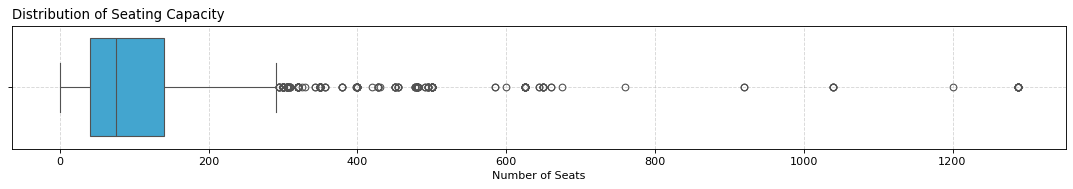

In [28]:
# Create a boxplot
plt.figure(num=None, figsize=(17, 2), dpi=80, edgecolor='white')
sns.boxplot(x=df['seats'], color='#2cafe6')
plt.title('Distribution of Seating Capacity', loc='left')
plt.xlabel('Number of Seats')
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.show()


The boxplot shows that most establishments have between 0 and approximately 300 seats, which corresponds to the range between the minimum and maximum values. However, there are significant outliers exceeding this range, reaching values above 1200 seats. This indicates that in Moscow there are several large establishments offering far more seating than most others.

Let's remove some of the outliers.


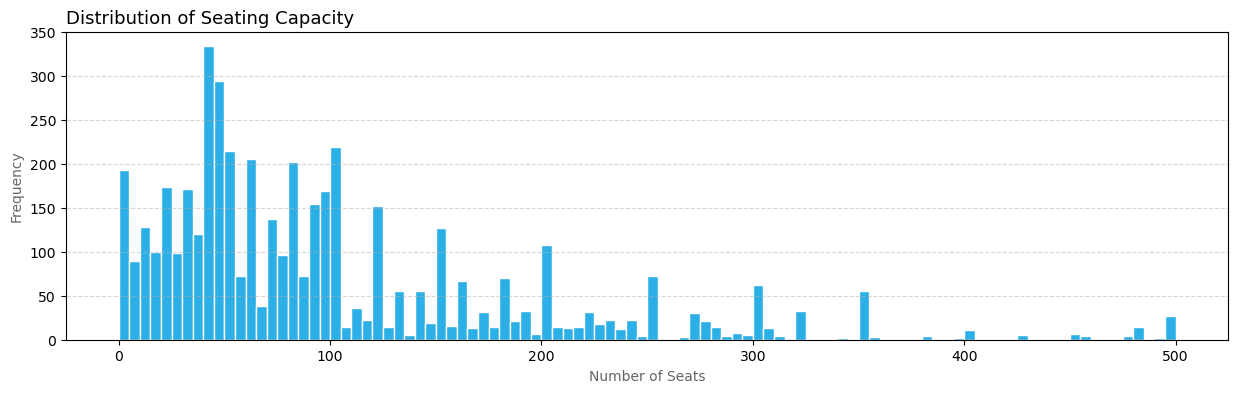

In [29]:
# Data filtering: select rows where the number of seats is <= 500
filtered_data = df[df['seats'] <= 500]

# Plotting the histogram
plt.figure(figsize=(15, 4))
plt.hist(filtered_data['seats'], bins=100, color='#2cafe6', edgecolor='white')
plt.title('Distribution of Seating Capacity', fontsize=13, loc='left')
plt.xlabel('Number of Seats', alpha=0.6)
plt.ylabel('Frequency', alpha=0.6)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


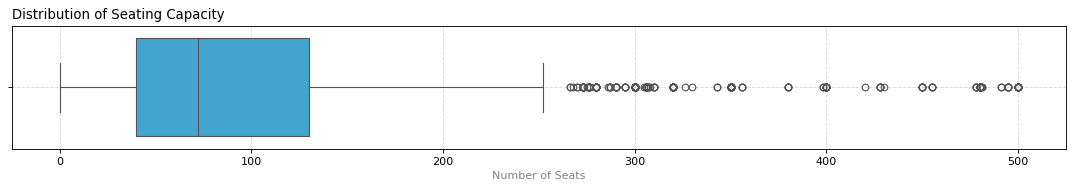

In [30]:
# Create a boxplot for the filtered data
plt.figure(num=None, figsize=(17, 2), dpi=80, edgecolor='white')
sns.boxplot(x=filtered_data['seats'], color='#2cafe6')
plt.title('Distribution of Seating Capacity', loc='left')
plt.xlabel('Number of Seats', color='gray')
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.show()


Most establishments have approximately between 40 and 130-140 seats, which corresponds to the main "box" in the boxplot. This is typical for small cafés, restaurants, and snack bars.

Let's check establishments with 0 and more than 1000 seats.


In [31]:
print("Number of establishments with more than 1000 seats:", df[df['seats'] > 1000].shape[0])


Number of establishments with more than 1000 seats: 16


In [32]:
df[df['seats'] > 1000].head()

,name,category,address,district,hours,lat,lng,rating,price,avg_bill,middle_avg_bill,middle_coffee_cup,chain,seats,district_short,street,is_24_7
2713,Ваня и Гоги,bars and pubs,"Москва, Измайловское шоссе, 71, корп. А",Восточный административный округ,"ежедневно, 11:00–06:00",55.789842,37.750282,4.2,высокие,Средний счёт:1000–2500 ₽,1750.0,NaN,0,1040,ВАО,Измайловское шоссе,False
2722,Маргарита,fast food,"Москва, Измайловское шоссе, 71, корп. А",Восточный административный округ,"ежедневно, 10:00–22:00",55.789527,37.752004,4.3,Не определено,NaN,NaN,NaN,1,1040,ВАО,Измайловское шоссе,False
2770,Шоколадница,coffee shop,"Москва, Измайловское шоссе, 71, корп. А",Восточный административный округ,"пн-ср 11:00–23:00; чт 11:00–00:00; пт,сб 11:00...",55.789903,37.749822,4.1,Не определено,NaN,NaN,NaN,1,1040,ВАО,Измайловское шоссе,False
2966,Матрешка,cafe,"Москва, Измайловское шоссе, 71, корп. А",Восточный административный округ,NaN,55.789867,37.749656,4.0,Не определено,NaN,NaN,NaN,0,1040,ВАО,Измайловское шоссе,False
4231,РестоБар Argomento,canteen,"Москва, Кутузовский проспект, 41, стр. 1",Западный административный округ,"ежедневно, 12:00–23:00",55.738237,37.531819,4.2,высокие,Средний счёт:2500–5000 ₽,3750.0,NaN,0,1200,ЗАО,Кутузовский проспект,False


These are relatively rare objects in the food and beverage market, implying high capacity for large events or heavy customer flows. Now, let's check how many establishments have 0 seats:


In [33]:
print("Number of establishments with 0 seats:", df[df['seats'] == 0].shape[0])
df[df['seats'] == 0]


Number of establishments with 0 seats: 136


,name,category,address,district,hours,lat,lng,rating,price,avg_bill,middle_avg_bill,middle_coffee_cup,chain,seats,district_short,street,is_24_7
84,Meat Doner Kebab,bakery,"Москва, улица Лескова, 22",Северо-Восточный административный округ,"ежедневно, круглосуточно",55.896987,37.608126,4.5,Не определено,Средний счёт:300 ₽,300.0,NaN,0,0,СВАО,улица Лескова,True
177,Арамье,bakery,"Москва, улица 800-летия Москвы, 22, корп. 2",Северный административный округ,"ежедневно, 09:00–21:00",55.879392,37.556832,4.0,Не определено,NaN,NaN,NaN,1,0,САО,улица 800-летия Москвы,False
196,Донер-Шашлык,restaurant,"Москва, улица Лескова, 22",Северо-Восточный административный округ,"ежедневно, круглосуточно",55.896962,37.608300,4.5,Не определено,NaN,NaN,NaN,0,0,СВАО,улица Лескова,True
203,Тандыр № 1,cafe,"Москва, улица Лескова, 22Г",Северо-Восточный административный округ,"ежедневно, круглосуточно",55.895615,37.611049,4.0,Не определено,NaN,NaN,NaN,1,0,СВАО,улица Лескова,True
211,Неаполитан пицца,cafe,"Москва, улица Пришвина, 23",Северо-Восточный административный округ,"ежедневно, 12:00–23:00",55.885416,37.604650,4.3,Не определено,NaN,NaN,NaN,0,0,СВАО,улица Пришвина,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8118,Бико,bakery,"Москва, улица Симоновский Вал, 13, стр. 3",Юго-Восточный административный округ,"ежедневно, 08:00–20:00",55.723340,37.664252,1.3,Не определено,NaN,NaN,NaN,0,0,ЮВАО,улица Симоновский Вал,False
8168,Чайхана УЧ Кудук,coffee shop,"Москва, улица Симоновский Вал, 26, корп. 1",Южный административный округ,"ежедневно, 09:00–00:00",55.718663,37.662887,4.3,Не определено,NaN,NaN,NaN,0,0,ЮАО,улица Симоновский Вал,True
8172,Масса кофе,coffee shop,"Москва, Холодильный переулок, 2",Южный административный округ,"пн-пт 08:00–20:00; сб,вс 09:00–20:00",55.709713,37.624388,4.3,средние,Цена чашки капучино:100–210 ₽,NaN,155.0,0,0,ЮАО,Холодильный переулок,False
8336,Сочная шаурма в Кузьминках,fast food,"Москва, Волгоградский проспект, 102",Юго-Восточный административный округ,"ежедневно, круглосуточно",55.703834,37.773831,3.9,Не определено,Средний счёт:120–130 ₽,125.0,NaN,0,0,ЮВАО,Волгоградский проспект,True


Establishments with "0 seats" are most likely small cafés, snack bars, or take-away outlets where the main format is quick purchase without the need for seating.
Now, let's analyze the seating capacity of establishments by categories: restaurants, cafés, coffee shops, pizzerias, bars, etc. Create visualizations. Analyze the results and draw conclusions.



In [34]:
df_grouped = (
    df.groupby('category', as_index=False)
      .agg({'seats': ['mean', 'median', 'min', 'max']})
)

# Round all numeric values to 2 decimal places
df_grouped = df_grouped.round(2)

# Rename columns to remove the multi-level index
df_grouped.columns = [
    'category', 
    'mean_seats', 
    'median_seats', 
    'min_seats', 
    'max_seats'
]

# Sort by the mean number of seats
df_grouped = df_grouped.sort_values(by='mean_seats', ascending=False)

df_grouped


,category,mean_seats,median_seats,min_seats,max_seats
1,bars and pubs,124.53,82.5,0,1288
7,restaurant,121.94,86.0,0,1288
4,coffee shop,111.2,80.0,0,1288
3,canteen,99.75,75.5,0,1200
5,fast food,98.89,65.0,0,1040
2,cafe,97.51,60.0,0,1288
6,pizzeria,94.5,55.0,0,1288
0,bakery,89.39,50.0,0,625


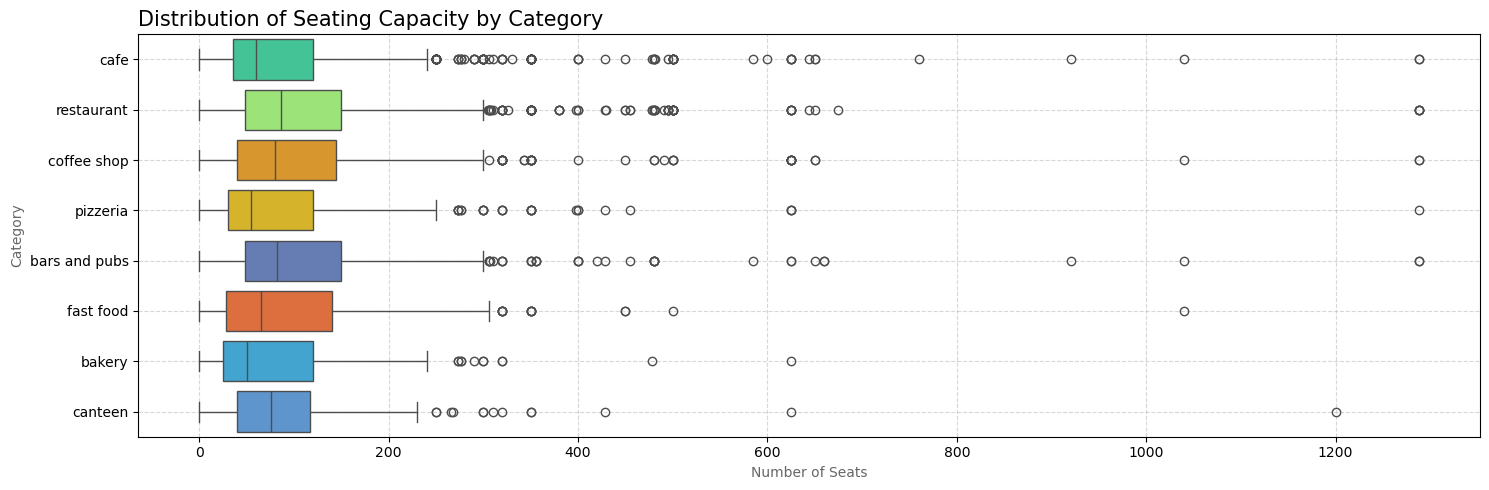

In [35]:
color_discrete_map = {
    'bars and pubs': '#5978c1',
    'fast food': '#f86524',
    'cafe': '#2fd89e',
    'restaurant': '#96f468',
    'coffee shop': '#f39c12',
    'pizzeria': '#f1c40f',
    'bakery': '#2cafe6',
    'canteen': '#4d95df'
}


# Plotting the boxplots
plt.figure(figsize=(15, 5))
sns.boxplot(
    data=df, 
    x='seats', 
    y='category', 
    hue='category',       # Use the y variable as hue
    palette=color_discrete_map, 
    dodge=False           # Disable dodging since there's only one box per category
)

# Graph settings
plt.title('Distribution of Seating Capacity by Category', fontsize=15, loc='left')
plt.xlabel('Number of Seats', fontsize=10, alpha=0.6)
plt.ylabel('Category', fontsize=10, alpha=0.6)
plt.grid(axis='both', linestyle='--', alpha=0.5)

# Remove the redundant legend
plt.legend([],[], frameon=False)

# Show the plot
plt.tight_layout()
plt.show()



Category "bars and pubs" has the highest average seating capacity (124.53) and median (82.5). Restaurants also show high figures: the average is 121.94 and the median is 86.0, with a maximum of 1288 seats. In contrast, the categories "Bakery" and "Pizzeria" have the lowest average seating capacities—89.39 and 94.50 respectively, with medians of 50.0 and 55.0 seats. The maximum values for all categories indicate the presence of significant outliers, such as establishments with more than 1000 seats.


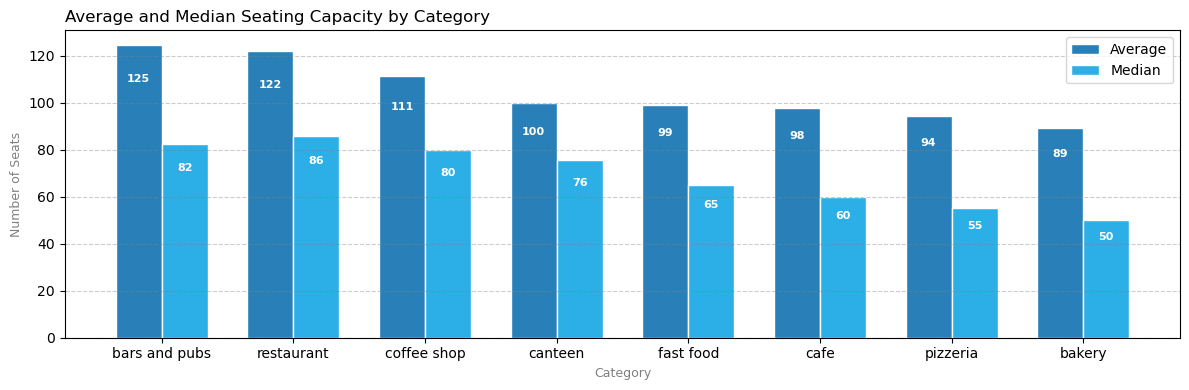

In [36]:
# Create a DataFrame with the seating capacity statistics (average and median) per category
df_category = df.groupby('category').agg({
    'seats': ['mean', 'median']
}).sort_values(by=('seats', 'mean'), ascending=False).reset_index()

# Flatten the MultiIndex in the columns
df_category.columns = ['category', 'mean', 'median']

# Parameters for plotting the graph
categories = df_category['category']
mean_values = df_category['mean']
median_values = df_category['median']

x = np.arange(len(categories))  # Positions for the categories
width = 0.35  # Width of the bars

# Plotting the grouped bar chart
fig, ax = plt.subplots(figsize=(12, 4))

# Bars for the average value
bars1 = ax.bar(x - width/2, mean_values, width, label='Average', 
               color='#2980b9', edgecolor='white')

# Bars for the median value
bars2 = ax.bar(x + width/2, median_values, width, label='Median', 
               color='#2cafe6', edgecolor='white')

# Graph settings
ax.set_xlabel('Category', fontsize=9, alpha=0.5)
ax.set_ylabel('Number of Seats', fontsize=9, alpha=0.5)
ax.set_title('Average and Median Seating Capacity by Category', loc='left')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.grid(True, which='major', axis='y', linestyle='--', color='gray', alpha=0.4)
ax.legend()

# Adding numbers inside the bars
for bar in bars1:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval - yval*0.1, f'{yval:.0f}', 
            ha='center', va='top', color='white', fontsize=8, fontweight='bold')

for bar in bars2:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval - yval*0.1, f'{yval:.0f}', 
            ha='center', va='top', color='white', fontsize=8, fontweight='bold')

# Show the plot
plt.tight_layout()
plt.show()


Categories "bars and pubs" and "restaurant" have the highest average seating capacities (over 120). Bakeries and pizzerias have the lowest average number of seats (around 90). For all categories, the median seating capacity is significantly lower than the average. This may indicate the presence of establishments with an extremely high seating capacity.


**Conclusion:**

**Seating Capacity Distribution**:
   - Most establishments have between 40 and 140 seats, which is typical for cafés, restaurants, and snack bars.
   - There are both very small establishments (0 seats) and large venues with more than 1000 seats.

**Average and Median Seating Capacity**:
   - Average: 108 seats.
   - Median: 75 seats.
   - The difference between the average and median values indicates the influence of large establishments on the average.

**High-Capacity Establishments**:
   - Establishments with more than 1000 seats are rare (16 objects), designed for large flows of customers.

**Category Analysis**:
   - Bars and restaurants have the highest average seating capacity (over 120).
   - Bakeries and pizzerias have the lowest average (around 90 seats).
   - The median seating capacity for all categories is lower than the average, which may suggest the presence of establishments with extreme seating capacities.


### Proportion of Chain and Non-Chain Establishments

Examine and visualize the proportion of chain versus non-chain establishments in the dataset. Which type of establishment is more common?


In [37]:
df.groupby('chain')['name'].count().to_frame()

,name
chain,
0,5201
1,3205


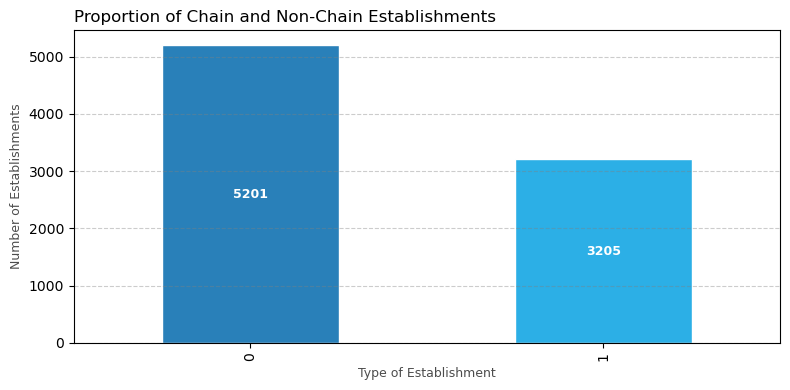

In [38]:
# Plot the graph
plt.figure(figsize=(8, 4)) 

# Grouping and plotting
ax = df.groupby('chain')['name'].count().plot(kind='bar', color=['#2980b9', '#2cafe6'], edgecolor='white')

# Graph settings
ax.set_xlabel('Type of Establishment', fontsize=9, alpha=0.7)
ax.set_ylabel('Number of Establishments', fontsize=9, alpha=0.7)
ax.set_title('Proportion of Chain and Non-Chain Establishments', loc='left')
ax.grid(True, which='major', axis='y', linestyle='--', color='gray', alpha=0.4)

# Adding numbers inside the bars
for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2, 
            p.get_height() * 0.5,  # Center the text vertically within the bar
            f'{int(p.get_height())}', 
            ha='center', va='center', 
            color='white', 
            fontsize=9, 
            fontweight='bold')

# Show the plot
plt.tight_layout()
plt.show()


Non-chain establishments number 5201, which is roughly one and a half times more than chain establishments (3205).

Let's examine the proportion of chain and non-chain establishments by category.


In [39]:
# Create a DataFrame with the count of chain and non-chain establishments by category
df_chain_category = df.groupby(['category', 'chain']).size().unstack(fill_value=0).reset_index()

# Rename columns for convenience
df_chain_category.columns = ['category', 'Non-Chain', 'Chain']

# Add a column with the total number of establishments
df_chain_category['Total'] = df_chain_category['Non-Chain'] + df_chain_category['Chain']

# Sort by the total number of establishments in descending order
df_chain_category = df_chain_category.sort_values(by='Total', ascending=False).reset_index(drop=True)

df_chain_category


,category,Non-Chain,Chain,Total
0,cafe,1599,779,2378
1,restaurant,1313,730,2043
2,coffee shop,693,720,1413
3,bars and pubs,596,169,765
4,pizzeria,303,330,633
5,fast food,371,232,603
6,canteen,227,88,315
7,bakery,99,157,256


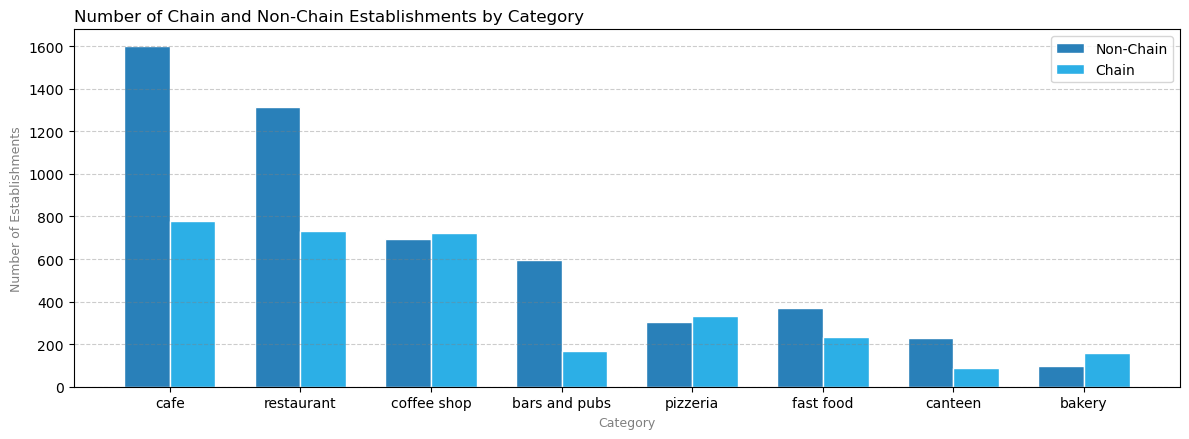

In [40]:
# Parameters for plotting the graph
categories = df_chain_category['category']
non_chain_values = df_chain_category['Non-Chain']
chain_values = df_chain_category['Chain']

x = np.arange(len(categories))  # Positions for categories
width = 0.35  # Width of the bars

# Plotting the grouped bar chart
fig, ax = plt.subplots(figsize=(12, 4.5))

# Bars for non-chain establishments
bars1 = ax.bar(x - width/2, non_chain_values, width, label='Non-Chain', 
               color='#2980b9', edgecolor='white')

# Bars for chain establishments
bars2 = ax.bar(x + width/2, chain_values, width, label='Chain', 
               color='#2cafe6', edgecolor='white')

# Graph settings
ax.set_xlabel('Category', fontsize=9, alpha=0.5)
ax.set_ylabel('Number of Establishments', fontsize=9, alpha=0.5)
ax.set_title('Number of Chain and Non-Chain Establishments by Category', loc='left')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=0)
ax.grid(True, which='major', axis='y', linestyle='--', color='gray', alpha=0.4)
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()


**Conclusion:**

- The dataset is dominated by non-chain establishments — 5201, compared to 3205 chain establishments.
- Cafés, restaurants, canteens, bars, and pubs are mainly non-chain.
- Pizzerias, coffee shops, and fast food outlets show a relatively balanced distribution between chain and non-chain establishments.
- Bakeries have more chain establishments, which may be related to the popularity of chain bakeries and bread franchise networks.


### Top-15 Popular Chains in Moscow

Group the data by establishment name and find the top-15 popular chains in Moscow. Here, popularity is defined as the number of establishments belonging to that chain in the region. Create an appropriate visualization for this information. Are you familiar with these chains? Is there any common characteristic that unites them? To which category of establishments do they belong?


In [41]:
# Filter only chain establishments and count by name
top_15_chains = df[df['chain'] == 1].groupby('name', as_index=False).agg(
    # Count the number of establishments
    count=('category', 'count'),
    # Keep the most frequent category (mode) for each chain
    category=('category', lambda x: x.mode()[0]) 
).sort_values('count', ascending=False).head(15)

top_15_chains


,name,count,category
746,Шоколадница,120,coffee shop
344,Домино'с Пицца,76,pizzeria
340,Додо Пицца,74,pizzeria
148,One Price Coffee,71,coffee shop
759,Яндекс Лавка,69,restaurant
59,Cofix,65,coffee shop
170,Prime,50,restaurant
679,Хинкальная,44,cafe
378,КОФЕПОРТ,42,coffee shop
431,Кулинарная лавка братьев Караваевых,39,cafe


In the top-15 popular chain establishments in Moscow, cafés and pizzerias dominate, with leaders such as Shokoladnitsa (120 establishments), Domino's Pizza, and Dodo Pizza. Coffee shops like One Price Coffee and Cofix also hold high positions. Yandex Lavka reflects the popularity of quick grocery delivery. In the segment of traditional cuisine, chains such as Teremok and Khinkalnaya are in demand.


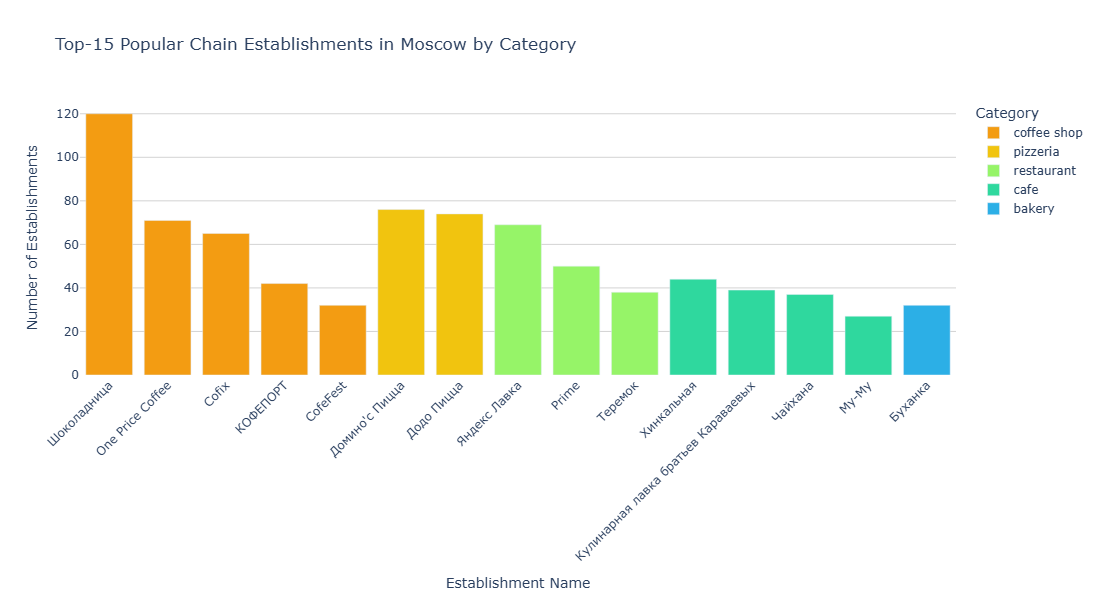

In [42]:
# Plot a bar chart using Plotly
fig = px.bar(
    top_15_chains, 
    x='name', 
    y='count', 
    color='category',  # Use color to show the category
    title='Top-15 Popular Chain Establishments in Moscow by Category',
    labels={
        'name': 'Establishment Name', 
        'count': 'Number of Establishments', 
        'category': 'Category'
    },
    color_discrete_map=color_discrete_map
)

# Configure display settings, chart size, and grid
fig.update_layout(
    xaxis_tickangle=-45,  # Rotate establishment names for readability
    width=1000,  # Chart width
    height=600,  # Chart height
    plot_bgcolor='rgba(0,0,0,0)',  # Transparent chart background
    yaxis=dict(
        showgrid=True,  # Enable horizontal grid lines
        gridcolor='lightgray',  # Y-axis grid line color
        gridwidth=1  # Grid line thickness
    )
)

# Show the chart
fig.show()


**Conclusion:**

   - In the top-15 popular chain establishments in Moscow, Shokoladnitsa leads with 120 establishments, which belongs to the café category. It is followed by pizzerias Домино'с Пицца (76 establishments) and Додо Пицца (74 establishments). Among coffee chains, One Price Coffee (71 establishments) and Cofix (65 establishments) also stand out. In the category of restaurants and cafés, chains such as Yandex Lavka (69 establishments) and Prime (50 establishments) are present.
   
   - The common characteristic that unites most establishments in the top-15 is their focus on quick service and affordable prices—especially popular are coffee shops and pizzerias.
   
   - The most frequently occurring categories among the top-15 chains are "coffee shop" (5 chains) and "café" (4 chains). Categories like "canteen", "bar, pub", and "fast food" are not included in the list.
   
   - There is one popular bakery chain — "Буханка".


### Distribution by Districts
Which administrative districts of Moscow are present in the dataset?  
Display the total number of establishments and the number of establishments for each category by district.  
Try to illustrate this information with a single graph.


In [43]:
# Build a crosstab with the number of establishments by district and category
pd.crosstab(df['district_short'], df['category'], margins=True)


category,bakery,bars and pubs,cafe,canteen,coffee shop,fast food,pizzeria,restaurant,All
district_short,,,,,,,,,
ВАО,25,53,272,40,105,71,72,160,798
ЗАО,37,50,239,24,150,62,71,218,851
САО,39,68,235,41,193,58,77,189,900
СВАО,28,63,269,40,159,82,68,182,891
СЗАО,12,23,115,18,62,30,40,109,409
ЦАО,50,364,464,66,428,87,113,670,2242
ЮАО,25,68,264,44,131,85,73,202,892
ЮВАО,13,38,282,25,89,67,55,145,714
ЮЗАО,27,38,238,17,96,61,64,168,709


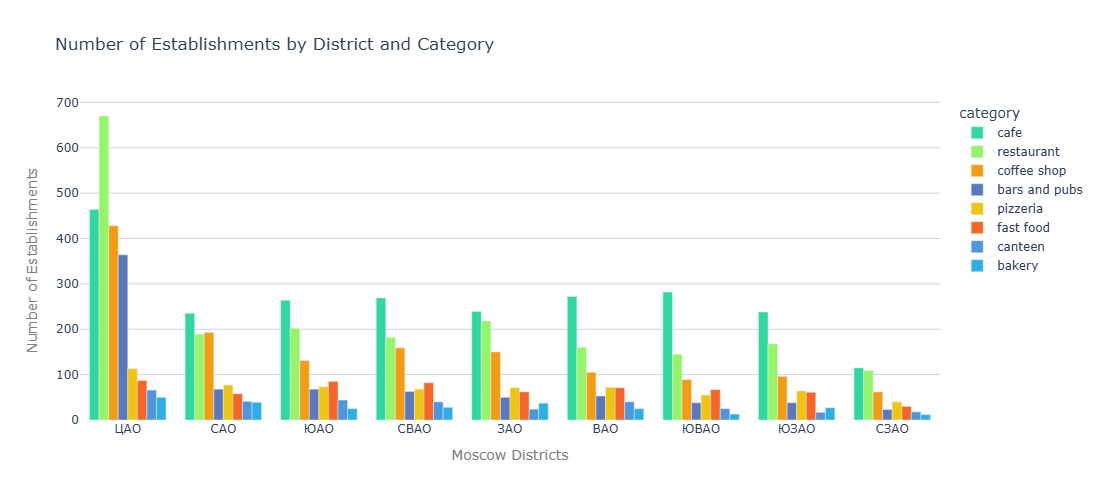

In [44]:
# Count the total number of establishments by district
total_districts = df.groupby('district_short').size().reset_index(name='total_count')

# Transform the main data and merge with the total number of establishments
districts = df.groupby(['district_short', 'category']).size().reset_index(name='count')
districts = districts.merge(total_districts, on='district_short')

# Count the total number of establishments for each category
total_category = df.groupby('category').size().reset_index(name='total_category_count')

# Merge the count of establishments by districts and categories with the overall totals by category
districts = districts.merge(total_category, on='category')

# Sort the data first by district, then by category in descending order
districts_sorted = districts.sort_values(by=['total_count', 'total_category_count'], 
                                         ascending=[False, False])


# Build a grouped bar chart
fig = px.bar(
    districts_sorted,
    x='district_short',
    y='count',
    color='category',
    barmode='group',
    title='Number of Establishments by District and Category',
    color_discrete_map=color_discrete_map
)

# Configure display settings, chart size, and grid
fig.update_layout(
    xaxis_tickangle=0,
    width=1100,
    height=500,
    plot_bgcolor='rgba(0,0,0,0)',
    xaxis_title='Moscow Districts',
    yaxis_title='Number of Establishments',
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',  # Color of the grid lines
        gridwidth=1  # Thickness of the grid lines
    ),
    xaxis_title_font=dict(color="gray"),
    yaxis_title_font=dict(color="gray"),
)

# Show the chart
fig.show()


**Conclusion:**

   - The Central Administrative Okrug (ЦАО) leads in terms of the number of establishments with 2242 locations. It is the only district where restaurants dominate (670). Other popular categories include cafés (464), coffee shops (428), and bars (364). This is due to the population density, a large number of workplaces, and cultural and tourist activities in the city center.

   - Districts such as the Northern, Southern, and Western Administrative Okrugs have about 900 establishments each, indicating a well-developed infrastructure. The most popular categories are cafés and restaurants. For example, in the Northern Administrative Okrug there are 235 cafés and 189 restaurants, while in the Southern Administrative Okrug there are 264 cafés and 202 restaurants.

   - The South-Eastern, South-Western, and North-Eastern Administrative Okrugs have around 700–900 establishments each. Cafés and restaurants remain the most in-demand categories, although there are fewer coffee shops in these districts compared to the Central Administrative Okrug.

   - The North-Western Administrative Okrug has the fewest establishments — 409. This indicates a lower density of infrastructure compared to other districts, although cafés and restaurants still remain the leading categories.


### Average Rating by Category

Visualize the distribution of average ratings by categories of establishments. Do the average ratings differ significantly among various types of food service?


In [45]:
# Display the 5 most frequent ratings
df['rating'].value_counts().head(10).to_frame()


,count
rating,
4.3,1513
4.4,1351
4.2,1041
4.1,785
4.5,623
4.0,499
4.7,440
4.6,422
3.9,252


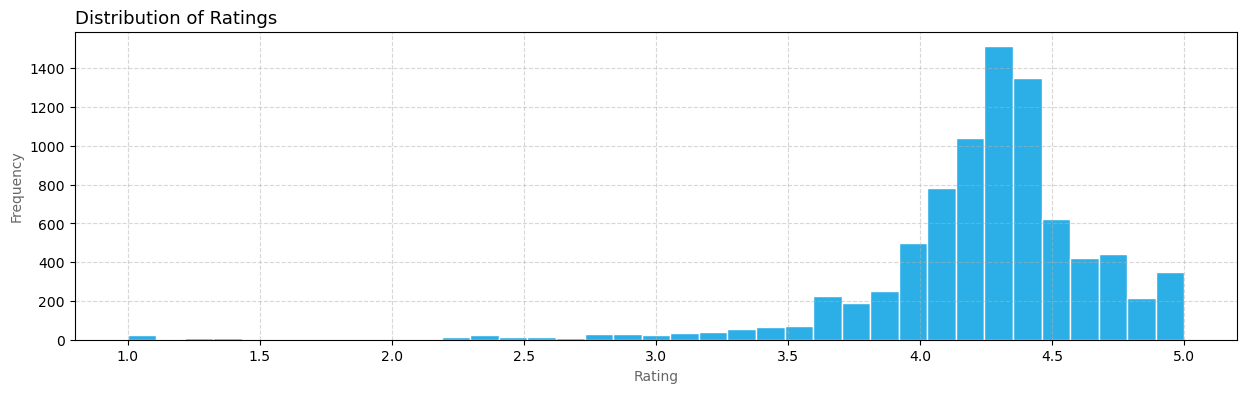

In [46]:
# Plot the histogram
plt.figure(figsize=(15, 4))
plt.hist(df['rating'], bins=37, color='#2cafe6', edgecolor='white')
plt.title('Distribution of Ratings', fontsize=13, loc='Left')
plt.xlabel('Rating', alpha=0.6)
plt.ylabel('Frequency', alpha=0.6)
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.show()


Most establishments have a rating between 4 and 4.5. The most common ratings are: 4.3 (1513 establishments), 4.4 (1351 establishments), and 4.2 (1041 establishments). Ratings below 4 are rarely encountered.


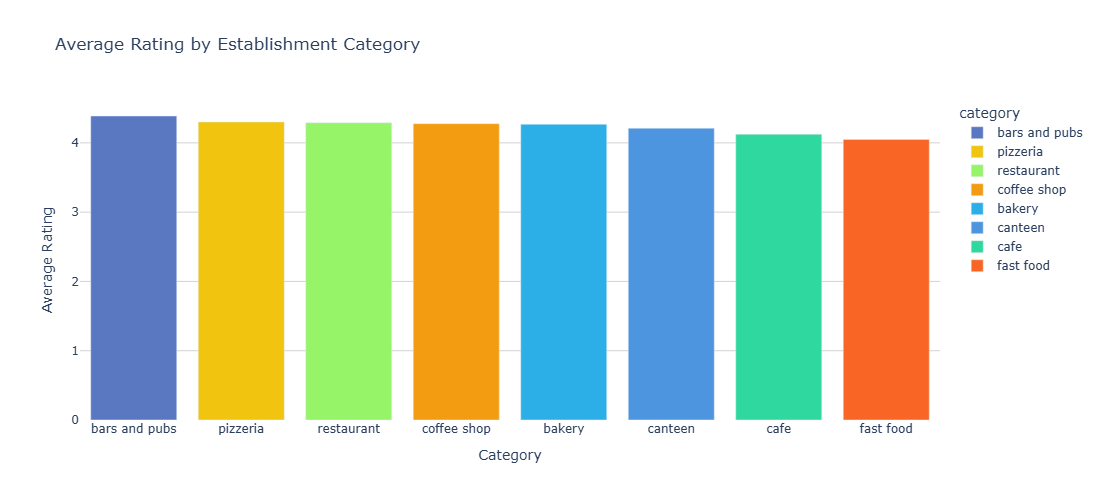

In [47]:
# Calculate the average rating by category
avg_ratings_by_category = df.groupby('category')['rating'].mean().reset_index(name='average_rating')

# Sort by descending average rating
avg_ratings_by_category = avg_ratings_by_category.sort_values(by='average_rating', ascending=False)

# Plot a bar chart
fig = px.bar(
    avg_ratings_by_category, 
    x='category', 
    y='average_rating', 
    title='Average Rating by Establishment Category',
    color='category', 
    color_discrete_map=color_discrete_map
)

# Configure display settings, chart size, and grid
fig.update_layout(
    xaxis_tickangle=0,
    width=1100, 
    height=500,
    plot_bgcolor='rgba(0,0,0,0)',
    xaxis_title='Category',  
    yaxis_title='Average Rating',  
    yaxis=dict(
        showgrid=True, 
        gridcolor='lightgray'
    )
)

# Show the chart
fig.show()


To better see the differences, we'll display the y-axis from 4 to 4.5.


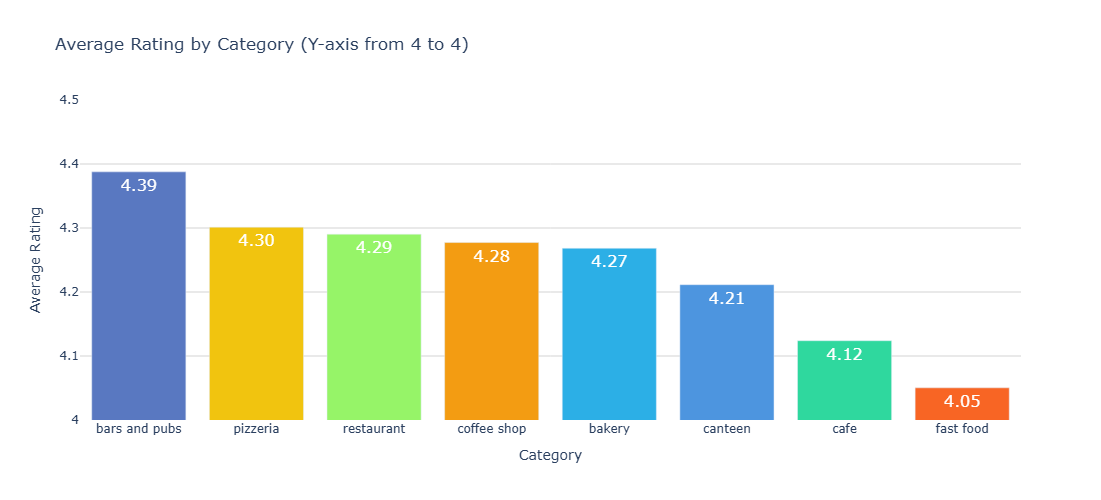

In [48]:
# Plot the bar chart
fig = px.bar(
    avg_ratings_by_category, 
    x='category', 
    y='average_rating', 
    title='Average Rating by Establishment Category',
    color='category', 
    text='average_rating',  # Add text on the bars
    color_discrete_map=color_discrete_map
)

# Configure display settings, chart size, and grid
fig.update_layout(
    title='Average Rating by Category (Y-axis from 4 to 4)', 
    xaxis_tickangle=0,
    width=1000, 
    height=500,
    plot_bgcolor='rgba(0,0,0,0)',
    xaxis_title='Category',  
    yaxis_title='Average Rating',  
    yaxis=dict(
        range=[4, 4.5],  # Y-axis from 4 to 4.5
        showgrid=True, 
        gridcolor='lightgray'
    ),
    showlegend=False  # Remove the legend
)

# Configure text inside the bars with bold font
fig.update_traces(texttemplate='%{text:.2f}', textposition='inside', 
                  textfont=dict(size=16, color='white'))

# Show the chart
fig.show()


**Conclusion:**

   - Most establishments have a rating between 4 and 4.5. The most common ratings are: 4.3 (1513 establishments), 4.4 (1351 establishments), and 4.2 (1041 establishments). Ratings below 4 are rarely encountered.

   - The highest average rating is observed in the "bars and pubs" category (4.39). High average ratings are also seen in the "pizzeria" (4.3), "restaurant" (4.29), and "coffee shop" (4.28) categories. The lowest average ratings are in the "fast food" (4.05) and "cafe" (4.12) categories.


#### Choropleth Map with the Average Rating of Establishments by District

Build a choropleth map with the average rating of establishments for each district.  
The boundaries of Moscow’s districts, as present in the dataset, are stored in the file `admin_level_geomap.geojson` (download the file for local work).


In [49]:
# File URL
url = "https://code.s3.yandex.net/data-analyst/admin_level_geomap.geojson"

# Download the file
response = requests.get(url)
response.raise_for_status()  # Check for errors

# Parse the content as JSON
geo_json = response.json()


In [50]:
# Aggregate average ratings by district (using 'district_short' if available)
avg_ratings_by_district = df.groupby('district', as_index=False)['rating'].mean()
avg_ratings_by_district.columns = ['district', 'average_rating']

# Check the resulting DataFrame
avg_ratings_by_district


,district,average_rating
0,Восточный административный округ,4.174185
1,Западный административный округ,4.181551
2,Северный административный округ,4.239778
3,Северо-Восточный административный округ,4.148260
4,Северо-Западный административный округ,4.208802
5,Центральный административный округ,4.377520
6,Юго-Восточный административный округ,4.101120
7,Юго-Западный административный округ,4.172920
8,Южный административный округ,4.184417


In [51]:
# File URL for the geojson file
url = "https://code.s3.yandex.net/data-analyst/admin_level_geomap.geojson"

# Download and parse the geojson file
response = requests.get(url)
response.raise_for_status()  # Check for errors
state_geo = response.json()

# Define the coordinates for Moscow's center
moscow_lat, moscow_lng = 55.751244, 37.618423

# Create a map of Moscow
m = Map(location=[moscow_lat, moscow_lng], zoom_start=10, tiles='Cartodb Positron')

# Create a choropleth layer using the aggregated district data
Choropleth(
    geo_data=state_geo,  # GeoJSON data from the web
    data=avg_ratings_by_district,  # DataFrame with district-level average ratings
    columns=['district', 'average_rating'],  # Columns to join on
    key_on='feature.properties.name',  # Adjust this based on your geojson structure
    fill_color='YlGn',  # Color scale
    fill_opacity=0.8,  # Opacity
    legend_name='Average Rating of Establishments by District'
).add_to(m)

# Display the map
#m

![map](docs/map.png)

Display all establishments from the dataset on the map using clustering via the `folium` library.


In [52]:
# Coordinates for the center of Moscow
moscow_lat, moscow_lng = 55.751244, 37.618423

# Create a map of Moscow
m = Map(location=[moscow_lat, moscow_lng], zoom_start=10)

# Create an empty marker cluster and add it to the map
marker_cluster = MarkerCluster().add_to(m)

# Define a function that takes a DataFrame row and adds a marker to the cluster
def create_clusters(row):
    Marker(
        [row['lat'], row['lng']],
        popup=f"{row['name']} {row['rating']}",
    ).add_to(marker_cluster)

# Apply the function to each row of the DataFrame
df.apply(create_clusters, axis=1)

# Display the map
#m


0       None
1       None
2       None
3       None
4       None
        ... 
8401    None
8402    None
8403    None
8404    None
8405    None
Length: 8406, dtype: object

![map](docs/map_2.png)

The map shows that the highest concentration of establishments is in the city center.


### Top-15 Streets by Number of Establishments

Find the top-15 streets with the highest number of establishments.  
Create a plot showing the distribution of the number of establishments and their categories across these streets.  
Try to illustrate all this information with a single graph.


In [53]:
df['street'].value_counts().head(15).to_frame()

,count
street,
проспект Мира,184
Профсоюзная улица,122
проспект Вернадского,108
Ленинский проспект,107
Ленинградский проспект,95
Дмитровское шоссе,88
Каширское шоссе,77
Варшавское шоссе,76
Ленинградское шоссе,70


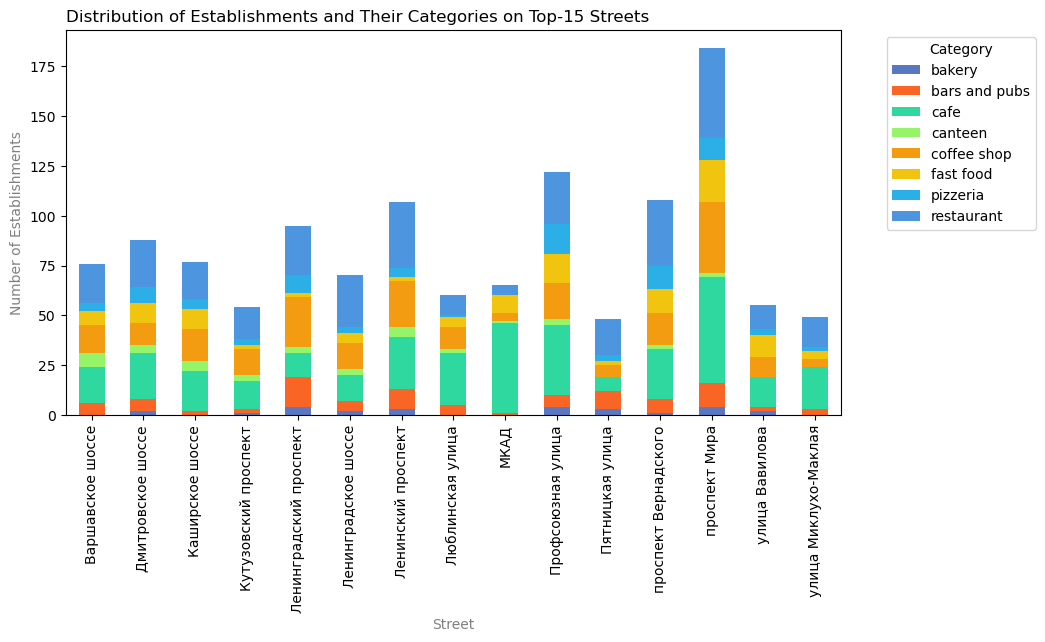

In [54]:
# Create a pivot table with the number of establishments by category for the top 15 streets
pivot_df = (
    df[df['street'].isin(df['street'].value_counts().head(15).index)]
    .pivot_table(index='street', columns='category', aggfunc='size', fill_value=0)
)

# Define custom colors for each category
category_colors = {
    'bars and pubs': '#5978c1', 
    'fast food': '#f86524', 
    'cafe': '#2fd89e',
    'restaurant': '#96f468',
    'coffee shop': '#f39c12', 
    'pizzeria': '#f1c40f',
    'bakery': '#2cafe6',
    'canteen': '#4d95df'
}


# Plot a stacked bar chart
pivot_df.plot(kind='bar', figsize=(10, 5), stacked=True, color=list(category_colors.values()))
plt.title("Distribution of Establishments and Their Categories on Top-15 Streets", loc='left')
plt.xlabel("Street", color='gray')
plt.ylabel("Number of Establishments", color='gray')
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


**Conclusion**

- The highest number of establishments is observed on **Проспект Мира** (184 establishments), **Профсоюзная улица** (122 establishments), and **проспект Вернадского** (108 establishments).

- The main categories of establishments on these streets are restaurants, coffee shops, and cafés. A significant portion also consists of fast food places and pizzerias, which may indicate high foot traffic and the popularity of quick meals in these locations.

- **МКАД** (Moscow Ring Road) stands out, as cafés are clearly the dominant category there.


### Streets with Only One Establishment

Find the streets that have only one food service establishment.  
What can be said about these establishments?


In [55]:
# Group the data by street and count the number of establishments on each street
street_counts = df.groupby('street').size().reset_index(name='count')

# Filter streets that have only one establishment
single_object_streets = street_counts[street_counts['count'] == 1]

# Merge with the original DataFrame to retain the category column
result_df = df.merge(single_object_streets[['street']], on='street', how='inner')

result_df


,name,category,address,district,hours,lat,lng,rating,price,avg_bill,middle_avg_bill,middle_coffee_cup,chain,seats,district_short,street,is_24_7
0,Дом обеда,canteen,"Москва, улица Бусиновская Горка, 2",Северный административный округ,пн-пт 08:30–18:30; сб 10:00–20:00,55.885890,37.493264,4.1,средние,Средний счёт:300–500 ₽,400.0,NaN,0,180,САО,улица Бусиновская Горка,False
1,7/12,cafe,"Москва, Прибрежный проезд, 7",Северный административный округ,"ежедневно, 10:00–22:00",55.876805,37.464934,4.5,Не определено,NaN,NaN,NaN,0,<NA>,САО,Прибрежный проезд,False
2,В парке вкуснее,coffee shop,"Москва, парк Левобережный",Северный административный округ,"ежедневно, 10:00–21:00",55.878453,37.460028,4.3,Не определено,NaN,NaN,NaN,1,<NA>,САО,парк Левобережный,False
3,Coffeekaldi's,coffee shop,"Москва, Угличская улица, 13, стр. 8",Северо-Восточный административный округ,"ежедневно, 09:00–22:00",55.900316,37.570558,4.1,средние,Средний счёт:500–800 ₽,650.0,NaN,1,<NA>,СВАО,Угличская улица,False
4,Чебуречная история,coffee shop,"Москва, ландшафтный заказник Лианозовский",Северо-Восточный административный округ,"ежедневно, 10:00–22:00",55.899845,37.570488,4.9,Не определено,NaN,NaN,NaN,1,<NA>,СВАО,ландшафтный заказник Лианозовский,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
453,Мираж,restaurant,"Москва, улица Шкулёва, 2А",Юго-Восточный административный округ,"пн-пт 11:00–23:00; сб,вс 11:00–00:00",55.693340,37.746231,4.7,Не определено,NaN,NaN,NaN,0,90,ЮВАО,улица Шкулёва,False
454,WTFcoffee,coffee shop,"Москва, улица Артюхиной, 14/8с1",Юго-Восточный административный округ,"ежедневно, 10:00–22:00",55.699044,37.737790,4.4,средние,NaN,NaN,NaN,0,<NA>,ЮВАО,улица Артюхиной,False
455,Беседка,cafe,"Москва, Кузьминская улица, 10",Юго-Восточный административный округ,"ежедневно, 11:00–23:00",55.690691,37.787735,4.1,Не определено,NaN,NaN,NaN,1,<NA>,ЮВАО,Кузьминская улица,False
456,Лагман Хаус,cafe,"Москва, Новороссийская улица, 14, стр. 2",Юго-Восточный административный округ,"ежедневно, 10:00–00:00",55.678772,37.759422,4.3,Не определено,NaN,NaN,NaN,1,40,ЮВАО,Новороссийская улица,True


In [56]:
# Check the number of establishments by category in the filtered dataset
result_df['category'].value_counts().to_frame()


,count
category,
cafe,160
restaurant,93
coffee shop,84
bars and pubs,39
canteen,36
fast food,23
pizzeria,15
bakery,8


The main categories of these establishments are:  
- Cafés: 160  
- Restaurants: 93  
- Coffee shops: 84  


In [57]:
# Check the number of such establishments by district
result_df['district_short'].value_counts().to_frame()


,count
district_short,
ЦАО,145
СВАО,55
САО,52
ВАО,52
ЮАО,43
ЮВАО,39
ЗАО,35
СЗАО,19
ЮЗАО,18


Most streets with only one establishment are located in **ЦАО** (145),  
and the fewest are in **ЮЗАО** (18).


**Conclusion**

There are **458** streets that have only one food establishment.  
The main categories of these single establishments are:  
- Cafés (160),  
- Restaurants (93),  
- Coffee shops (84).  

The highest number of such establishments is located in **ЦАО** (145),  
and the lowest in **ЮЗАО** (18).


### Average Check Values of Establishments

The values of average checks are stored in the `middle_avg_bill` column.  
These numbers represent the approximate cost of an order in rubles, often given as a range.  
Calculate the **median** of this column for each district and use it as a **price indicator** for the district.  
Build a choropleth map using the obtained values. Analyze the prices in the Central Administrative District and others.  
How does the distance from the center affect food prices?


In [61]:
# Group by district and compute the median of the average bill
# Sort in descending order

median_bill_by_district = (
    df.groupby('district', as_index=False)['middle_avg_bill']
      .median()
      .sort_values(by='middle_avg_bill', ascending=False)
)

median_bill_by_district


,district,middle_avg_bill
1,Западный административный округ,1000.0
5,Центральный административный округ,1000.0
4,Северо-Западный административный округ,700.0
2,Северный административный округ,650.0
7,Юго-Западный административный округ,600.0
0,Восточный административный округ,575.0
3,Северо-Восточный административный округ,500.0
8,Южный административный округ,500.0
6,Юго-Восточный административный округ,450.0


The highest average checks are in the Central and Western districts (1000 RUB),  
and the lowest is in the South-Eastern district.


In [62]:
# Create a map of Moscow
m2 = Map(location=[moscow_lat, moscow_lng], zoom_start=10)

# Create a choropleth using the Choropleth constructor and add it to the map
Choropleth(
    geo_data=state_geo,
    data=median_bill_by_district,
    columns=['district', 'middle_avg_bill'],
    key_on='feature.name',
    legend_name='Average Check of Establishments by District',
).add_to(m2)

# Display the map
#m2


![map](docs/map_3.png)

**Conclusion:**  
It can be assumed that **distance from the city center correlates with a decrease in the average check** at food establishments.  
Central districts and those adjacent to them have higher prices, while in more remote areas the average check is significantly lower.  
Additionally, prices in the **western half** of Moscow tend to be **higher** than in the eastern half.

- **Central Administrative District (ЦАО)** and **Western Administrative District (ЗАО)** have the highest average checks — **1000 RUB**.  
  This is typical for central areas, where prices are higher due to expensive rent, popularity, and a wealthier clientele.

- **North-Western (СЗАО)** and **Northern (САО)** Administrative Districts also show relatively high checks — **700 and 650 RUB** respectively.  
  These could be adjacent or more prestigious areas in socio-economic terms.

- **South-Western (ЮЗАО)** and **Eastern (ВАО)** Administrative Districts have slightly lower checks — **600 and 575 RUB** respectively,  
  suggesting a gradual decrease in average price with increasing distance from the center.

- **North-Eastern (СВАО)**, **Southern (ЮАО)**, and **South-Eastern (ЮВАО)** districts have the lowest checks — **500 and 450 RUB**.  
  This may be related to lower income levels and more affordable rent, which allows establishments to offer lower prices.


### General Summary:

**Main types of establishments** are `cafés` and `restaurants`, which together cover **52.6%** of the market. These two types hold key positions and shape the majority of consumer preferences.

- `Cafés` are the most common category, accounting for **28.3%** of all establishments (2,378).
- `Restaurants` come second, covering **24.3%** of the market (2,043).
- `Coffee shops` make up **16.8%** (1,413).
- `Bars and pubs` account for **9.1%** (765).
- `Pizzerias` hold **7.53%** (633).
- `Fast food` covers **7.17%** of the market (603).
- `Canteens` represent **3.75%** (315).
- `Bakeries` have the smallest share at **3.05%** (256).

---

**Seating capacity distribution**:  
Most establishments have between 40 and 140 seats — typical for `cafés`, `restaurants`, and `fast casual` places.  
There are also very small venues (0 seats) and some large ones with over 1000 seats (only 16 such establishments). These are rare and likely serve large flows of customers.

- Average number of seats: 108; median: 75.  
  The gap between the average and the median suggests the presence of a few large venues that raise the average.
- The highest average seating capacity is observed in `bars` and `restaurants` (over 120).  
  `Bakeries` and `pizzerias` have the lowest averages (around 90).  
  The median is lower than the mean across all categories, indicating the presence of establishments with extremely large capacity.

---

**Chain vs. non-chain establishments**:  
The dataset is dominated by non-chain venues — 5,201 vs. 3,205 chain ones.

- `Cafés`, `restaurants`, `canteens`, and `bars and pubs` are mainly non-chain.
- `Pizzerias`, `coffee shops`, and `fast food` have a relatively even distribution between chain and non-chain.
- `Bakeries` tend to be chain-based — likely due to the popularity of franchise bakery chains.

---

**Top-15 most popular chains in Moscow**:  
`Shokoladnitsa` leads with 120 venues (coffee shop category), followed by pizzerias: `Domino's Pizza` (76) and `Dodo Pizza` (74).  
Popular coffee chains include `One Price Coffee` (71) and `Cofix` (65).  
In the restaurant and café categories, we see `Yandex Lavka` (69) and `Prime` (50).

- Most chains in the top-15 focus on **quick service and affordable pricing**, especially coffee shops and pizzerias.
- Most common categories: "`coffee shop`" (5 chains) and "`café`" (4 chains).  
  Notably absent: "`canteen`", "`bar/pub`", "`fast food`".
- One notable bakery chain: `"Bukhanka"`.

---

**District distribution**:  
The **Central Administrative District (CAD / ЦАО)** leads with **2,242 establishments**.  
It is the only district where `restaurants` dominate (670).  
Other popular categories include `cafés` (464), `coffee shops` (428), and `bars` (364).  
This reflects high population density, many workplaces, and active cultural/tourist life in the city center.

- Northern, Southern, and Western districts have around 900 establishments each, indicating developed infrastructure.  
  Top categories: `cafés` and `restaurants`.  
  For example: Northern District has 235 cafés and 189 restaurants; Southern has 264 cafés and 202 restaurants.
- South-Eastern, South-Western, and North-Eastern districts have around 700–900 venues each.  
  `Cafés` and `restaurants` dominate, but `coffee shops` are less common than in the center.
- The North-Western district has the fewest establishments — only **409**, indicating a lower infrastructure density, although `cafés` and `restaurants` are still leading categories.

---

**Average rating by category**:  
Most establishments have ratings between 4.0 and 4.5.  
Most common scores: **4.3** (1,513), **4.4** (1,351), and **4.2** (1,041).  
Ratings below 4 are relatively rare.

- The highest average rating goes to `bars and pubs` (4.39).  
  High average scores are also seen in `pizzerias` (4.3), `restaurants` (4.29), and `coffee shops` (4.28).  
  The lowest are in `fast food` (4.05) and `cafés` (4.12).

---

**Top-15 streets by number of establishments**:  
Most establishments are located on:
- **Prospekt Mira** (184),
- **Profsoyuznaya Street** (122),
- **Vernadsky Avenue** (108).

- Dominant categories: `restaurants`, `coffee shops`, and `cafés`.  
  A significant share on these streets also comes from `fast food` and `pizzerias`,  
  suggesting high foot traffic and demand for quick meals.
- The **MKAD** (Moscow Ring Road) stands out — most venues here are `cafés`.

---

**Streets with only one establishment**:  
There are **458** such venues.  
Top categories: `cafés` (160), `restaurants` (93), and `coffee shops` (84).  
The majority are located in **CAD / ЦАО** (145); the fewest in **SWAD / ЮЗАО** (18).

---

**Average check values**:  
Distance from the city center **correlates with lower average checks** in food establishments.  
Central districts and those adjacent to them tend to have higher prices, while more remote areas are notably cheaper.  
Also, prices in the **western part of Moscow** are generally higher than in the eastern part.

- **Central (ЦАО)** and **Western (ЗАО)** districts have the **highest average checks** — 1,000 RUB.  
  This is typical for central areas, where higher rent, demand, and wealthier clientele lead to higher prices.

- **North-Western (СЗАО)** and **Northern (САО)** districts also have relatively high checks — 700 and 650 RUB respectively.  
  These may be adjacent or more affluent areas.

- **South-Western (ЮЗАО)** and **Eastern (ВАО)** districts have slightly lower checks — 600 and 575 RUB respectively,  
  indicating a gradual price drop away from the center.

- **North-Eastern (СВАО)**, **Southern (ЮАО)**, and **South-Eastern (ЮВАО)** districts have the **lowest average checks** — 500 and 450 RUB.  
  This could reflect lower average incomes and cheaper rent, enabling businesses to charge less.


## Step 4. Detailing the Study: Opening a Coffee Shop


The founders of the “Shut Up and Take My Money” fund are inspired by the success of the series Friends.
Their dream is to open a cozy and accessible coffee shop in Moscow, just like Central Perk.
They are not afraid of competition, even though coffee shops are already widespread in big cities.
Let’s explore whether their dream is feasible.


#### Overview of Coffee Shops
How many coffee shops are in the dataset? In which districts are they most concentrated, and what are the characteristics of their locations?

In [63]:
# Let's count the number of coffee shops in the dataset
print('Number of coffee shops in the dataset:', df[df['category'] == 'кофейня'].shape[0])


Number of coffee shops in the dataset: 0


In [64]:
# Create a DataFrame with coffee shops
df_cofeinya = df[df['category'] == 'coffee shop']
df_cofeinya['district_short'].value_counts().to_frame()

,count
district_short,
ЦАО,428
САО,193
СВАО,159
ЗАО,150
ЮАО,131
ВАО,105
ЮЗАО,96
ЮВАО,89
СЗАО,62


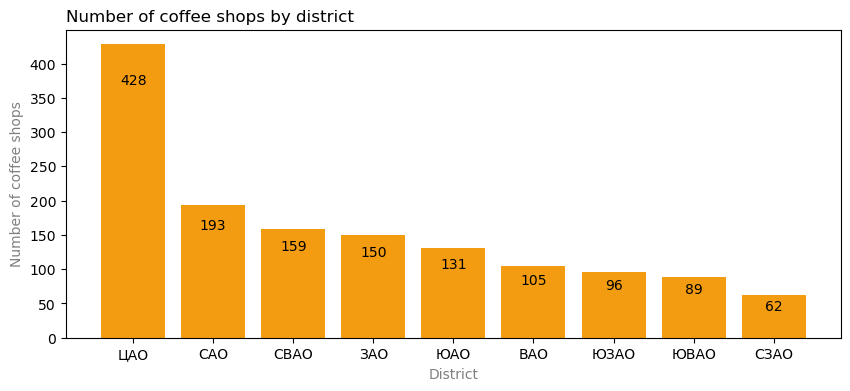

In [65]:
# Create a DataFrame with the number of coffee shops per district
df_cofeinya_count = df_cofeinya['district_short'].value_counts().to_frame().reset_index()
df_cofeinya_count.columns = ['district_short', 'count']  # Rename columns for convenience

# Plot a bar chart
plt.figure(figsize=(10, 4))
plt.bar(df_cofeinya_count['district_short'], df_cofeinya_count['count'], color='#f39c12')
plt.xlabel('District', color='gray')
plt.ylabel('Number of coffee shops', color='gray')
plt.title('Number of coffee shops by district', loc='left')
plt.xticks(rotation=0)

# Add value labels inside the bars
for i, value in enumerate(df_cofeinya_count['count']):
    plt.text(i, value - (value * 0.1), str(value), ha='center', va='top', fontsize=10, color='black')

plt.show()

The highest number of coffee shops is in the Central Administrative District (428 establishments),  
likely due to high population density, the number of tourists, and business activity in the city center.  
Next is the Northern Administrative District (193 coffee shops), followed by the North-Eastern and Western Districts with 159 and 150 respectively.  
The lowest number is in the North-Western District (62 establishments).

In [66]:
# Create a map
moscow_lat, moscow_lng = 55.751244, 37.618423
m = Map(location=[moscow_lat, moscow_lng], zoom_start=10)
marker_cluster = MarkerCluster().add_to(m)
df_cofeinya.apply(create_clusters, axis=1)
#m

3       None
25      None
45      None
46      None
52      None
        ... 
8356    None
8365    None
8376    None
8385    None
8400    None
Length: 1413, dtype: object

![map](docs/map_4.png)

The highest concentration of coffee shops is in the Central District, especially around metro interchange stations:  
Mendeleevskaya/Novoslobodskaya (16), Paveletskaya (11), Park Kultury (12), Barrikadnaya (10),  
Taganskaya/Marksistskaya (10), Novokuznetskaya/Tretyakovskaya (10).  
These are high-traffic areas with offices and tourist attractions.

In [67]:
# Find the top 5 streets with the most coffee shops
df_cofeinya['street'].value_counts().head().to_frame()

,count
street,
проспект Мира,36
Ленинградский проспект,25
Ленинский проспект,23
Профсоюзная улица,18
проспект Вернадского,16


Most coffee shops are located on Prospekt Mira (36), followed by Leningradsky Prospekt (25),  
Leninsky Prospekt (23), Profsoyuznaya Street (18), and Vernadsky Avenue (16).  
These streets are partly in the Central and Western Districts.


In general, coffee shops are found on major and busy streets such as Prospekt Mira, Leningradsky, and Leninsky Prospekts.  
These streets have high foot and car traffic, are near business/shopping centers, universities, and important transit points.  
Coffee shops strategically position themselves to maximize foot traffic and revenue.

In [68]:
# Find the top 5 streets with the most coffee shops
top_streets = df_cofeinya['street'].value_counts().head().index
df_cofeinya_max = df_cofeinya[df_cofeinya['street'].isin(top_streets)]

# Create a map
moscow_lat, moscow_lng = 55.751244, 37.618423
m = Map(location=[moscow_lat, moscow_lng], zoom_start=10)
marker_cluster = MarkerCluster().add_to(m)
df_cofeinya_max.apply(create_clusters, axis=1)
#m

960     None
986     None
1019    None
1057    None
1101    None
        ... 
7002    None
7017    None
7056    None
7670    None
7995    None
Length: 118, dtype: object

![map](docs/map_5.png)

On Prospekt Mira, most coffee shops are located near *Prospekt Mira* metro and the Botanical Garden “Aptekarsky Ogorod” (12),  
*Alekseyevskaya* metro (6), and *VDNKh* (10).

On Leningradsky Prospekt: 8 near *Sokol*, 7 near *Aeroport*, and 8 near *Dynamo* stations.  
Shops are more spread out compared to Prospekt Mira.

Leninsky Prospekt, Profsoyuznaya, and Vernadsky Avenue are close to each other in the Western/South-Western Districts.  
Notable clusters include *Yugo-Zapadnaya* metro (7 coffee shops) and *Kaluzhskaya* depot (6).

**Conclusion:**  
The number of coffee shops decreases as we move away from the city center.  
Most are located on major, high-traffic streets such as Prospekt Mira, Leningradsky, and Leninsky Prospekts,  
which are partially within the Central and Western Districts. These areas offer developed infrastructure, proximity to business centers,  
and transit hubs that draw in large crowds. Coffee shops choose such locations to maximize customer flow and revenue.

The Central Administrative District (ЦАО) has the most coffee shops (428).  
Key concentrations are at metro interchanges: Mendeleevskaya/Novoslobodskaya (16),  
Paveletskaya (11), Park Kultury (12), Barrikadnaya (10), Taganskaya/Marksistskaya (10), and Novokuznetskaya/Tretyakovskaya (10).

The Northern District follows with 193 coffee shops, then North-Eastern (159), and Western (150).  
The lowest is in the North-Western District (62).

Top streets by number of coffee shops:  
- Prospekt Mira (36),  
- Leningradsky Prospekt (25),  
- Leninsky Prospekt (23),  
- Profsoyuznaya Street (18),  
- Vernadsky Avenue (16).  

Aside from the cluster near *Prospekt Mira* metro, the high number of shops is also explained by the size and length of these streets.

### 24/7 Coffee Shops

Are there any 24/7 coffee shops?


In [69]:
df_cofeinya['is_24_7'].value_counts().to_frame()

,count
is_24_7,
False,1344
True,69


Only 4.9% of coffee shops operate 24/7.


In [70]:
# Let's look at the distribution of 24/7 coffee shops by district
df_cofeinya[df_cofeinya['is_24_7'] == True]['district_short'].value_counts().to_frame()


,count
district_short,
ЦАО,30
ЗАО,11
ЮЗАО,8
САО,6
ВАО,5
СВАО,3
СЗАО,2
ЮВАО,2
ЮАО,2


Most 24/7 coffee shops are located in the Central District (30),  followed by the Western District (11), and the South-Western District (8).
).

In [71]:
# Map of 24/7 coffee shops
moscow_lat, moscow_lng = 55.751244, 37.618423  # Moscow center coordinates

# Create a map of Moscow
m = Map(location=[moscow_lat, moscow_lng], zoom_start=10)
marker_cluster = MarkerCluster().add_to(m)

# Add 24/7 coffee shops to the cluster
df_cofeinya[df_cofeinya['is_24_7'] == True].apply(create_clusters, axis=1)

# Display the map
#m


200     None
971     None
1047    None
1214    None
1291    None
        ... 
6890    None
7528    None
7668    None
7923    None
8168    None
Length: 69, dtype: object

![map](docs/map_6.png)

In [72]:
# Streets with the most 24/7 coffee shops
df_cofeinya[df_cofeinya['is_24_7'] == True]['street'].value_counts().head(10).to_frame()


,count
street,
Ленинский проспект,3
Комсомольская площадь,3
МКАД,3
Кутузовский проспект,3
Зелёный проспект,2
Рублёвское шоссе,2
Павелецкая площадь,2
Кудринская площадь,2
Ярославское шоссе,2


The most common streets for 24/7 coffee shops are:  Leninsky Prospekt — 3 shops, Komsomolskaya Square — 3 shops, MKAD — 3 shops.  These are usually major transport hubs or areas with high pedestrian traffic. The highest concentration (5 shops) is near the Three Railway Stations Square — which makes sense. 


### Conclusion

- **69 coffee shops** (4.9% of the total) operate **24/7**.
- The **Central Administrative District (ЦАО)** leads with **30** such establishments, followed by:
  - the **Western District (ЗАО)** – 11 coffee shops,
  - the **South-Western District (ЮЗАО)** – 8 coffee shops.
- Streets with the highest number of 24/7 coffee shops:
  - **Leninsky Prospekt** – 3 shops  
  - **Komsomolskaya Square** – 3 shops  
  - **MKAD** – 3 shops
- These locations are typically **major roads or transport hubs** (e.g., railway stations, highways, gas stations).
- The **highest concentration** (5 shops) is found **near the Square of the Three Railway Stations**, which is logical given the constant flow of people.

### Coffee Shop Ratings
What are the ratings of coffee shops? How are they distributed across districts?


In [73]:
# Display the top 5 most frequent ratings
df_cofeinya['rating'].value_counts().head(10).to_frame()


,count
rating,
4.3,261
4.4,228
4.2,202
4.1,170
4.5,95
4.0,78
4.7,77
4.6,61
3.9,38


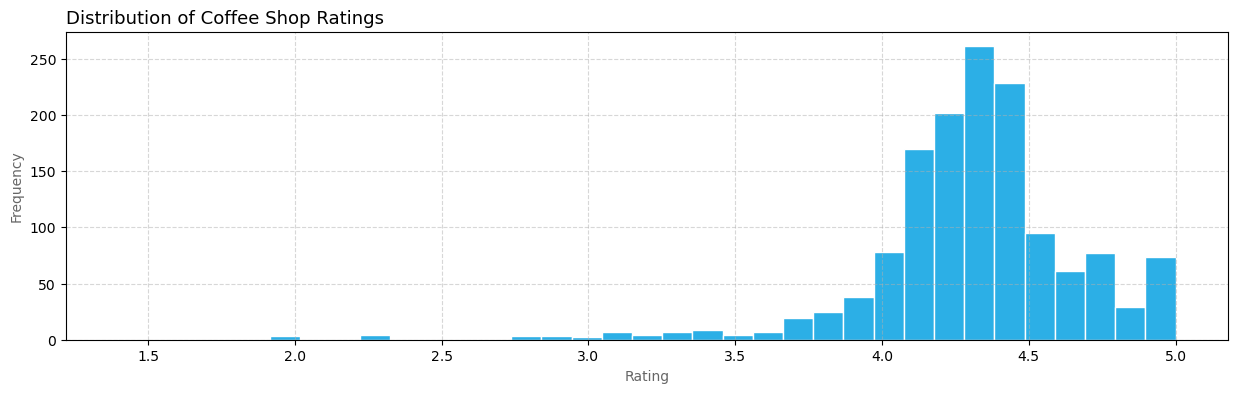

In [74]:
# Build a histogram
plt.figure(figsize=(15, 4))
plt.hist(df_cofeinya['rating'], bins=35, color='#2cafe6', edgecolor='white')
plt.title('Distribution of Coffee Shop Ratings', fontsize=13, loc='Left')
plt.xlabel('Rating', alpha=0.6)
plt.ylabel('Frequency', alpha=0.6)
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.show()


Most coffee shops have a rating between 4.0 and 4.5.
The most frequent ratings are: 4.3 (261 shops), 4.4 (228), and 4.2 (202).
Ratings below 4 are relatively rare.

In [75]:
# Group by district and calculate the average rating for coffee shops
ratings_by_district = df_cofeinya.groupby('district_short')['rating'].mean().sort_values(ascending=False)
ratings_by_district.to_frame()


,rating
district_short,
ЦАО,4.336449
СЗАО,4.325806
САО,4.291710
ЮЗАО,4.283333
ВАО,4.282857
ЮАО,4.232824
ЮВАО,4.225843
СВАО,4.216981
ЗАО,4.195333


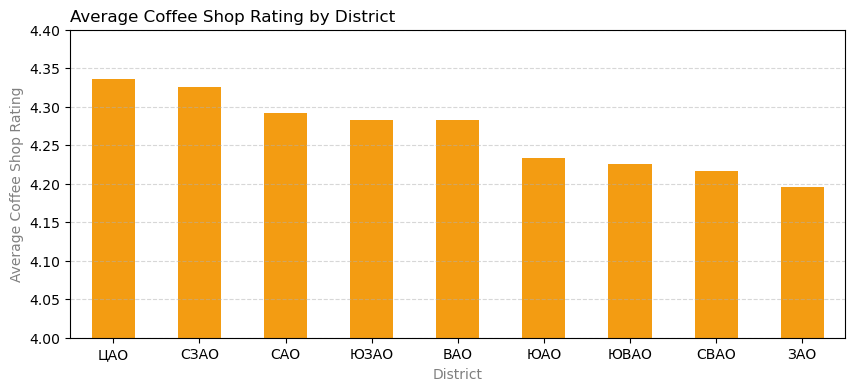

In [76]:
# Rename district names using the dictionary
ratings_by_district = ratings_by_district.rename(index=district_rename)

# Build barplot
plt.figure(figsize=(10, 4))
ratings_by_district.plot(kind='bar', color='#f39c12')
plt.xlabel('District', color='gray')
plt.ylabel('Average Coffee Shop Rating', color='gray')
plt.title('Average Coffee Shop Rating by District', loc='left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=0)
plt.ylim(4, 4.4)
plt.show()


**Observations by District** 

- The **Central Administrative District (ЦАО)** has the **highest average coffee shop rating** — **4.34**.  
  This suggests **higher service standards** and a strong focus on **meeting the expectations of demanding customers**.

- High average ratings are also observed in:
  - **North-Western District (СЗАО)** – 4.33  
  - **Northern District (САО)** – 4.29

- The **Western Administrative District (ЗАО)** has the **lowest average rating** — **4.20**,  
  which may indicate that coffee shops there do not meet customer expectations as consistently as in higher-rated areas.

**Conclusion**

- The **average rating for the "coffee shop" category** is **4.28**, which is **above average** compared to other types of venues —  
  only **bars and pubs** score higher, while **canteens, cafés**, and **fast food** venues fall behind.

- The **rating distribution** resembles that of other food establishments in Moscow:  
  most coffee shops are rated between **4.0 and 4.5**, with peaks at:
  - **4.3** – 261 coffee shops  
  - **4.4** – 228  
  - **4.2** – 202  
  Ratings **below 4.0** are **rare**.

- **Average ratings by district** fall within a **narrow range** of **4.19 to 4.34**,  
  pointing to **consistent quality** of coffee shops across the city.

- **Higher ratings in central and northern districts** may be driven by **competition and demand**,  
  motivating coffee shops to deliver **better products and service**.

### Estimated Price of a Cappuccino
What price should be targeted for a cappuccino when opening a new coffee shop, and why?

To start, let’s check how many coffee shops we have, how many missing, and how many filled values in the “Price of one cappuccino” column.

In [77]:
print('Number of coffee shops in the dataset:', len(df_cofeinya))
print('Number of missing values in the "Price of one cappuccino" column:', 
      df_cofeinya['middle_coffee_cup'].isna().sum())
print('Number of filled values in the "Price of one cappuccino" column:', 
      len(df_cofeinya) - df_cofeinya['middle_coffee_cup'].isna().sum())


Number of coffee shops in the dataset: 1413
Number of missing values in the "Price of one cappuccino" column: 892
Number of filled values in the "Price of one cappuccino" column: 521


In [78]:
# Let’s view the highest values in this column
print('Maximum values in the "Price of one cappuccino" column:')
df_cofeinya['middle_coffee_cup'].sort_values(ascending=False).head().to_frame()


Maximum values in the "Price of one cappuccino" column:


,middle_coffee_cup
2859,1568.0
5503,375.0
3718,328.0
1769,325.0
5990,320.0


In [79]:
print('Minimum value in the "Price of one cappuccino" column:', df_cofeinya['middle_coffee_cup'].min())


Minimum value in the "Price of one cappuccino" column: 60.0


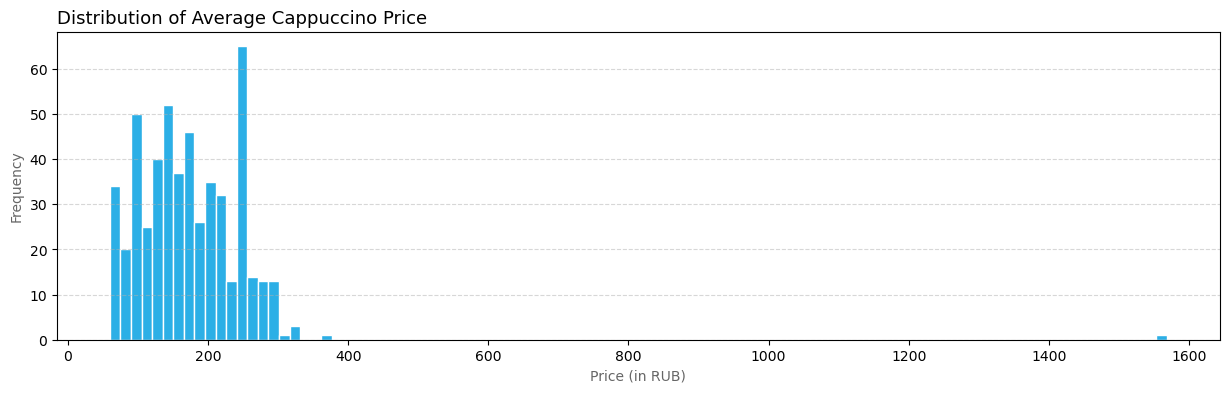

In [80]:
# Plot a histogram
plt.figure(figsize=(15, 4))
plt.hist(df_cofeinya['middle_coffee_cup'], bins=100, color='#2cafe6', edgecolor='white')
plt.title('Distribution of Average Cappuccino Price', fontsize=13, loc='Left')
plt.xlabel('Price (in RUB)', alpha=0.6)
plt.ylabel('Frequency', alpha=0.6)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


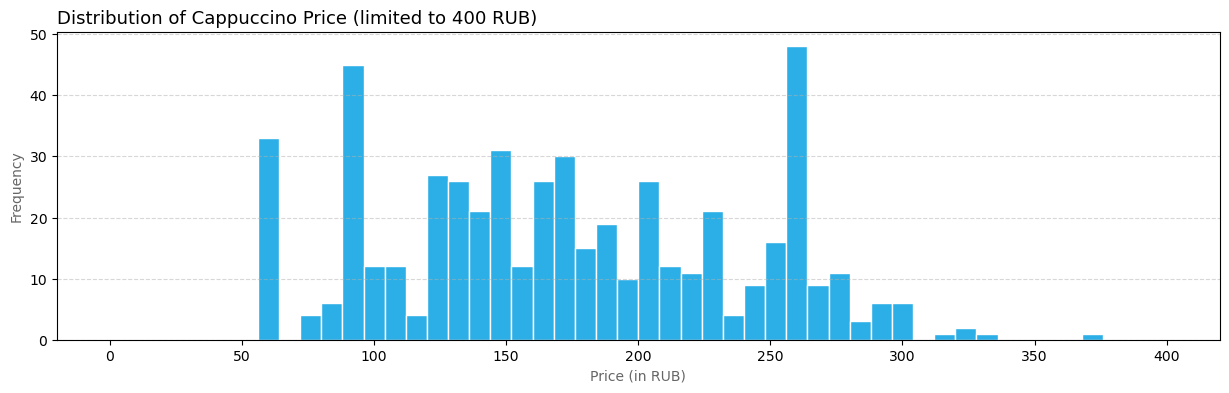

In [81]:
# Plot a histogram with a price limit of 400 RUB
plt.figure(figsize=(15, 4))
plt.hist(df_cofeinya['middle_coffee_cup'], bins=50, range=(0, 400), color='#2cafe6', edgecolor='white')
plt.title('Distribution of Cappuccino Price (limited to 400 RUB)', fontsize=13, loc='left')
plt.xlabel('Price (in RUB)', alpha=0.6)
plt.ylabel('Frequency', alpha=0.6)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


The price of one cappuccino ranges from 60 to 375 RUB. There is one outlier — 1568 RUB.

Let’s check what this outlier establishment is:

In [82]:
df_cofeinya[df_cofeinya['middle_coffee_cup'] == 1568]

,name,category,address,district,hours,lat,lng,rating,price,avg_bill,middle_avg_bill,middle_coffee_cup,chain,seats,district_short,street,is_24_7
2859,Шоколадница,coffee shop,"Москва, Большая Семёновская улица, 27, корп. 1",Восточный административный округ,"ежедневно, 08:00–23:00",55.782268,37.709022,4.2,средние,Цена чашки капучино:230–2907 ₽,NaN,1568.0,1,48,ВАО,Большая Семёновская улица,False


The cappuccino price at this Shokoladnitsa location has a wide range. Most likely, it’s the price of a large-size drink or a special menu item.


Let’s get a statistical description of the data:

In [83]:
df_cofeinya['middle_coffee_cup'].describe().to_frame()

,middle_coffee_cup
count,521.000000
mean,175.055662
std,89.753009
min,60.000000
25%,124.000000
50%,170.000000
75%,225.000000
max,1568.000000


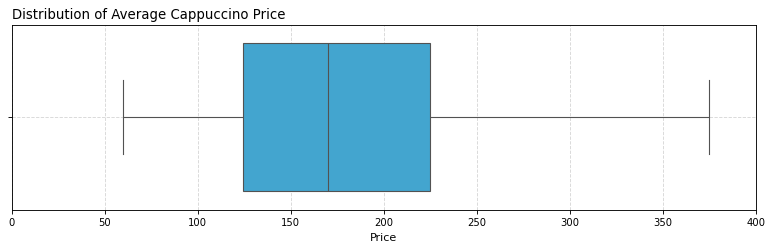

In [84]:
plt.figure(num=None, figsize=(12, 3), dpi=80, edgecolor='white')
sns.boxplot(x=df_cofeinya['middle_coffee_cup'], color='#2cafe6')
plt.title('Distribution of Average Cappuccino Price', loc='left')
plt.xlabel('Price')
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.xticks(np.arange(0, 1700, 50), size=9)
plt.xlim(0, 400)
plt.show()


**Conclusion:**  
Most coffee shops offer cappuccinos priced between **124 and 225 RUB**, with a typical price around **170 RUB**. However, some high-end places have much higher prices, which increases data variance.

- **Average price** of a cappuccino: ~175 RUB  
- **Median**: 170 RUB — very close to the average, indicating a relatively symmetric distribution  
- **Minimum price**: 60 RUB  
- **Maximum price**: 1568 RUB (likely a data error or special case)

- **25th percentile**: 124 RUB  
- **75th percentile**: 225 RUB  
  → This shows that 50% of coffee shops fall within this price range — a good benchmark.

- **Standard deviation**: ~90 RUB — indicating moderate variability, suggesting a range of offers from budget to premium options.

#### Estimated Cappuccino Price in the Central Administrative District (CAD)

Assuming the coffee shop is to be opened in CAD — possibly on one of the popular streets — this indicates existing demand for coffee. So let’s explore cappuccino prices in the central district in more detail.

In [85]:
df_cofeinya_cao = df_cofeinya[df_cofeinya['district_short'] == 'ЦАО']
df_cofeinya_cao['middle_coffee_cup'].describe().to_frame()

,middle_coffee_cup
count,162.000000
mean,187.518519
std,67.263201
min,60.000000
25%,139.000000
50%,190.000000
75%,250.000000
max,328.000000


Based on the cappuccino price statistics in the Central Administrative District, we can conclude:

**Average price**: 188 RUB — slightly above the citywide average.

**Median (50th percentile)**: 190 RUB — close to the average, suggesting a relatively symmetrical distribution.

**25%** of coffee shops offer cappuccino for less than 139 RUB, and **75%** for less than 250 RUB — i.e., the main price range is 139–250 RUB.

**Min** price: 60 RUB; **Max**: 328 RUB — the price range reflects a variety of establishments from budget to premium.

Overall, prices in CAD vary, but most cafés stick to the 139–250 RUB range.

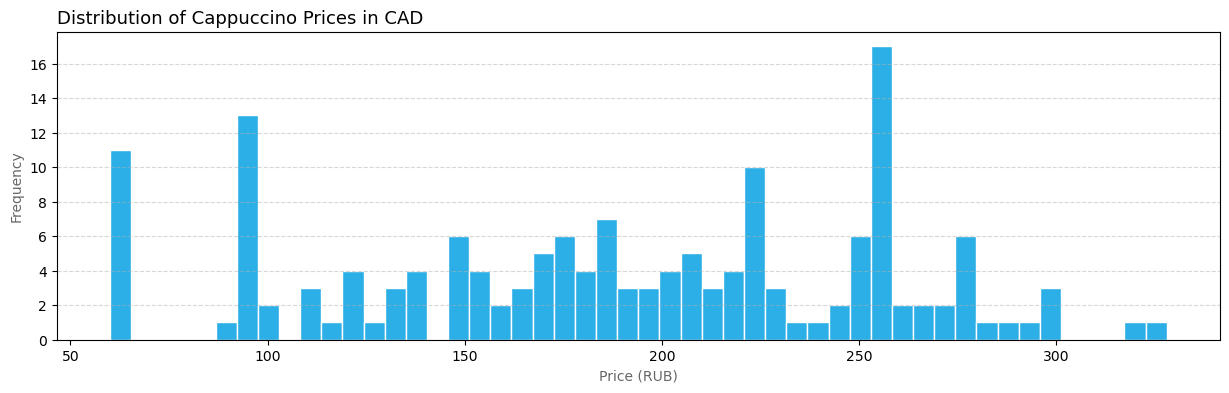

In [86]:
# Histogram of average cappuccino price in CAD
plt.figure(figsize=(15, 4))
plt.hist(df_cofeinya_cao['middle_coffee_cup'], bins=50, color='#2cafe6', edgecolor='white')
plt.title('Distribution of Cappuccino Prices in CAD', fontsize=13, loc='Left')
plt.xlabel('Price (RUB)', alpha=0.6)
plt.ylabel('Frequency', alpha=0.6)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


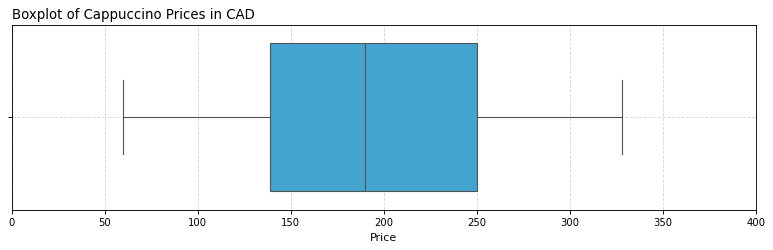

In [87]:
plt.figure(num=None, figsize=(12, 3), dpi=80, edgecolor='white')
sns.boxplot(x=df_cofeinya_cao['middle_coffee_cup'], color='#2cafe6')
plt.title('Boxplot of Cappuccino Prices in CAD', loc='left')
plt.xlabel('Price')
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.xticks(np.arange(0, 1700, 50), size=9)
plt.xlim(0, 400)
plt.show()


Let’s see which establishments offer cappuccino for 60 RUB, and which are below 139 RUB (25th percentile):

In [88]:
df_cofeinya_cao['name'][df_cofeinya_cao['middle_coffee_cup'] == 60].value_counts().to_frame()

,count
name,
Cofix,10
CofAir,1


In [89]:
df_cofeinya_cao[df_cofeinya_cao['middle_coffee_cup'] == 60].head()

,name,category,address,district,hours,lat,lng,rating,price,avg_bill,middle_avg_bill,middle_coffee_cup,chain,seats,district_short,street,is_24_7
2372,Cofix,coffee shop,"Москва, Краснопрудная улица, 26",Центральный административный округ,"ежедневно, 07:00–22:00",55.779418,37.666604,4.2,Не определено,Цена чашки капучино:от 60 ₽,NaN,60.0,1,45,ЦАО,Краснопрудная улица,False
3525,Cofix,coffee shop,"Москва, улица Пресненский Вал, 8к3",Центральный административный округ,пн-сб 07:00–23:00; вс 09:00–23:00,55.764731,37.564294,4.3,низкие,Цена чашки капучино:от 60 ₽,NaN,60.0,1,<NA>,ЦАО,улица Пресненский Вал,False
3671,Cofix,coffee shop,"Москва, Садовая-Кудринская улица, 7",Центральный административный округ,"ежедневно, 08:00–22:00",55.761243,37.585681,4.3,Не определено,Цена чашки капучино:от 60 ₽,NaN,60.0,1,<NA>,ЦАО,Садовая-Кудринская улица,False
4203,Cofix,coffee shop,"Москва, улица Остоженка, 42/2",Центральный административный округ,"ежедневно, 07:30–22:00",55.737619,37.594953,4.3,Не определено,Цена чашки капучино:от 60 ₽,NaN,60.0,1,40,ЦАО,улица Остоженка,False
4271,CofAir,coffee shop,"Москва, улица Воздвиженка, 9",Центральный административный округ,"ежедневно, 07:00–22:00",55.752687,37.605222,4.3,низкие,Цена чашки капучино:от 60 ₽,NaN,60.0,0,<NA>,ЦАО,улица Воздвиженка,False


The price of 60 RUB is the minimum, not average. It’s offered by chains like Cofix and the café CofAir. This price may not be the best benchmark.

In [90]:
# Top 5 streets with the most coffee shops
top_streets = df_cofeinya['street'].value_counts().head().index

# Filter the original DataFrame by these streets
df_cofeinya_max = df_cofeinya[df_cofeinya['street'].isin(top_streets)]

# Show results
print('Most frequent cappuccino prices on the streets with the highest number of coffee shops:')
df_cofeinya_max['middle_coffee_cup'].value_counts().head().to_frame()


Most frequent cappuccino prices on the streets with the highest number of coffee shops:


,count
middle_coffee_cup,
256.0,4
95.0,3
225.0,2
60.0,2
200.0,2


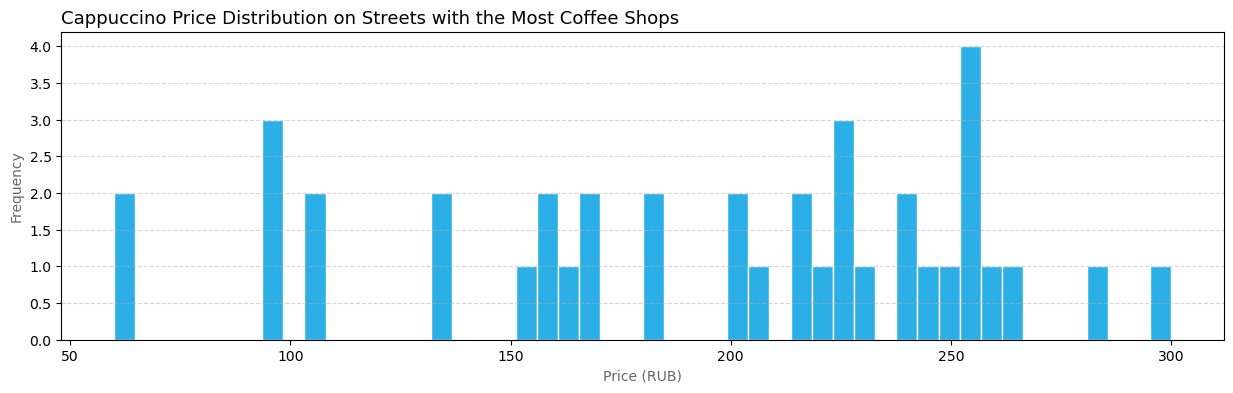

In [91]:
# Histogram of cappuccino prices on top streets
plt.figure(figsize=(15, 4))
plt.hist(df_cofeinya_max['middle_coffee_cup'], bins=50, color='#2cafe6', edgecolor='white')
plt.title('Cappuccino Price Distribution on Streets with the Most Coffee Shops', fontsize=13, loc='Left')
plt.xlabel('Price (RUB)', alpha=0.6)
plt.ylabel('Frequency', alpha=0.6)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


In [92]:
# Price segments of coffee shops in CAD
df_cofeinya_cao['price'].value_counts().to_frame()


,count
price,
Не определено,248
средние,144
низкие,15
высокие,14
выше среднего,7


Most coffee shops with specified price segments fall into the mid-range category.

**Conclusion:** The Central Administrative District (CAD) is a promising location to open a coffee shop, especially on streets with a high number of establishments, indicating strong demand. The **average cappuccino price** in CAD is 188 RUB, and the **median** is 190 RUB — both slightly above the city average, which reflects a solvent audience.

The **core price range** for cappuccino in CAD is 139–250 RUB, covering both budget and premium segments. Most coffee shops with a defined price category belong to the **mid-range**.

The **minimum price** is 60 RUB and the **maximum** is 328 RUB, pointing to a wide range of offerings. Therefore, when opening a coffee shop in CAD, aiming for a cappuccino price in the 139–250 RUB range aligns with the market and appeals to a broad audience.

### Overall Conclusion

**Total Number of Coffee Shops in the Dataset**: 1413

**Number of Coffee Shops by District**

As one moves away from the city center, the number of coffee shops decreases. Most coffee shops are located on major, bustling streets such as Prospekt Mira, Leningradsky Prospekt, and Leninsky Prospekt, which partly belong to the CAO (Central Administrative Okrug) and the ZAO (Western Administrative Okrug). These streets, with high foot traffic and well-developed infrastructure near business and shopping centers, as well as important transportation hubs, attract a large number of visitors. Coffee shops choose such locations to maximize customer flow and revenue.

The largest concentration of coffee shops is in the **Central Administrative Okrug** (428 establishments). The highest clustering of coffee shops is near metro stations in the center, at intersections of circular and radial metro lines: Mendeleyevskaya/Novoslobodskaya (16 coffee shops), Paveletskaya (metro and train station) (11 coffee shops), Park Kultury (12 coffee shops), Barrikadnaya (10 coffee shops), Taganskaya/Marksistskaya (10 coffee shops), and Novokuznetskaya/Tretyakovskaya (10 coffee shops)—that is, in areas with high foot traffic, offices, and attractions.

The **Northern Administrative Okrug** comes in second (193 coffee shops), followed by the **North-Eastern** and **Western Administrative Okrugs** with 159 and 150 coffee shops respectively. The fewest coffee shops are found in the **North-Western Administrative Okrug** (62 establishments).

The streets with the highest number of coffee shops are Prospekt Mira (36), Leningradsky Prospekt (25), Leninsky Prospekt (23), Profsoyuznaya Street (18), and Vernadsky Prospekt (16). Overall, apart from the clustering of coffee shops near the Prospekt Mira metro station, it cannot be said that there are more coffee shops there than in other areas; the explanation for the high number is the size of the streets.

**24/7 Coffee Shops**

A total of 69 (4.9%) coffee shops operate 24/7. Most of them are located in the CAO (30 coffee shops), followed by the ZAO (11 coffee shops) and the YUAO (8 coffee shops). The streets with the highest number of 24/7 coffee shops are Leninsky Prospekt (3 coffee shops), Komsomolskaya Square (3 coffee shops), and the MKAD (3 coffee shops). These streets and major roadways are typically major transportation hubs or are located in areas with high foot traffic (train stations, gas stations, etc.). The highest concentration of 24/7 coffee shops (5 in total) is found in the area around the Three Stations Square.

**Coffee Shop Ratings**

The average rating for the "coffee shop" category is **4.28**. Coffee shops hold middle positions, ranking below bars and pubs, but ahead of categories such as canteens, cafes, and fast-food establishments.

The distribution of ratings mirrors the overall ratings of food establishments in Moscow. Most coffee shops have ratings between **4.0** and **4.5**. The most common ratings are: **4.3** (261 coffee shops), **4.4** (228 coffee shops), and **4.2** (202 coffee shops). Ratings below **4.0** are relatively rare.

Overall, the average rating of coffee shops across districts ranges narrowly from **4.19 to 4.34**, indicating stable service quality throughout Moscow. Higher ratings are noted in the CAO (**4.34**) and some northern districts (SZAO — **4.33**, SAO — **4.3**), which may be related to competition and high demand that motivate establishments to improve service quality and products.

**Estimated Price of a Cup of Cappuccino**

Most coffee shops in the city offer a cappuccino priced between 124 and 225 rubles, with a typical price around 170 rubles. The **average price** is approximately 175 rubles, and the **median** is 170 rubles, indicating a relatively symmetric price distribution, although there are some outliers. The range of 124 to 225 rubles covers 50% of all establishments, which can be considered the typical price corridor. However, there are both budget options starting at 60 rubles and premium offerings with a maximum price of 375 rubles.

In the CAO, the **average cost** of a cappuccino is higher — around 188 rubles (with a median of 190 rubles). The primary price range for cappuccino in the CAO is from 139 to 250 rubles, covering both budget and premium segments. In this area, establishments cater to different income levels: the minimum price here is 60 rubles, and the maximum is 328 rubles.

---

### Recommendations for Opening a Coffee Shop in Moscow Based on Market Research

**Location:**

Focus on areas with a high flow of people, especially in the Central Administrative Okrug (CAO), as there is high demand and a willingness to pay more for coffee here. The CAO, with its developed infrastructure, offices, and business centers, has the highest number of coffee shops, making it an attractive location. Intersections of metro stations, such as Paveletskaya, Park Kultury, and Novoslobodskaya, can be ideal for attracting a large flow of customers.

**Pricing Strategy:**

Set the price for a cappuccino within the typical range for Moscow (from 124 to 225 rubles), aiming for a median price of 170 rubles to attract a broad audience. If the coffee shop is planned to be in the CAO, you can set a slightly higher price (within the range of 139–250 rubles), which corresponds to the average cost of a cappuccino in this district. This will help position the establishment as premium, attracting more affluent customers.

**Operating Hours:**

Consider operating the coffee shop 24/7, especially if it is located near transportation hubs (train stations or major thoroughfares) or busy streets like Leninsky Prospekt or Komsomolskaya Square, where there is high foot traffic during the evening and night hours. A round-the-clock schedule can attract customers who need coffee at any time of day.

**Service Quality and Ratings:**

The average rating of coffee shops in Moscow is about **4.28**, and in the CAO it is **4.34**. Aim to maintain high service and product quality to achieve a leading position. In highly competitive areas, such as the CAO, good reviews and high ratings can be a key factor in attracting and retaining customers.

**Unique Offerings:**

In a highly competitive market, you can stand out by offering unique products: add signature drinks to the menu, offer seasonal or unique flavors, and include options for vegans or people with lactose intolerance. Introducing loyalty programs, discounts, or promotions for regular customers can increase visitor traffic and help build a loyal customer base.

**Analysis of Areas with Less Competition:**

Consider the possibility of opening a coffee shop in areas with fewer establishments (for example, in the North-Western Administrative Okrug, or SZAO), where competition is lower but there are also affluent consumers. This could allow the coffee shop to quickly gain loyal customers and secure its niche.

**Economic Feasibility:**

Analyze the relationship between the rental rate, the average cost of coffee, and the expected foot traffic in the chosen areas. To do this, select locations with an optimal balance between high foot traffic (for example, metro stations, shopping centers, business districts) and reasonable rental costs. Calculate the minimum number of cups of coffee that need to be sold to cover rental and operating expenses, in order to assess the economic sustainability of the business in each area. Take into account data on peak and off-peak traffic to forecast revenues based on the time of day and days of the week.